# Paquetes

In [3]:
# Análisis de datos 
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.impute import KNNImputer
from itertools import combinations, product

# Visualización
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Ruta y df

In [5]:
# Función para encontrar el archivo CSV
def encontrar_csv(root=Path.cwd()):
    ruta_csv= Path().resolve().parent / "data" / "raw" / "dataset_regresion.csv"
    if ruta_csv.exists():
        return ruta_csv
    elif root != root.parent:
        root = root.parent
        return encontrar_csv(root)
    else:
        raise FileNotFoundError("No se encontró el archivo dataset_Regresión.csv en el directorio actual ni en los directorios superiores.")

ruta_csv = encontrar_csv()
print("Usando ruta:", ruta_csv)

df = pd.read_csv(ruta_csv)

df.columns = df.columns.str.strip()

df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]

print(f"Dimensiones: {df.shape}")

df.head()



Usando ruta: C:\Users\Lykos\Desktop\Python_codes\Analitica_de_datos\Mi_Proyecto\ml-project\data\raw\dataset_regresion.csv
Dimensiones: (894, 31)


,University Admission year,Gender,Age (Years),H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily? (Hours ),How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly Family Income
0,2021,Female,22,2019.0,BCSE,4,Yes,No,2,2,...,NETWORKING,Single,No,Bachelor,No,3.80,No,3.64,35.0,32500.0
1,2021,Male,22,2019.0,BCSE,4,No,No,3,2,...,"Software, Hardware, NETWORKING, Artificial Int...",Single,No,Bachelor,Yes,3.40,No,3.53,35.0,20000.0
2,2021,Male,20,2020.0,BCSE,4,Yes,Yes,2,1,...,"Software, Machine Learning / Deep Learning, Ar...",Single,Yes,Family,No,3.93,No,3.89,35.0,30000.0
3,2021,Male,21,2020.0,BCSE,4,Yes,No,1,2,...,"Software, Artificial Intelligence",In a relationship,No,Family,No,3.10,No,3.50,35.0,40000.0
4,2021,Female,21,2019.0,BCSE,4,Yes,No,3,2,...,Web development,Single,Yes,Bachelor,No,3.81,No,3.65,34.0,30000.0


# 1. Corrección de datos inconsistentes e imputación

# Corrección de datos

In [6]:
columnas=list(df.columns)

# Valores inconsistentes o erróneos en las columnas

valor1=df[columnas[25]].unique()[2]
valor2=df[columnas[26]].unique()[135]
valor3=df[columnas[28]].unique()[161]

# Reemplazo

df[columnas[25]] = df[columnas[25]].replace(valor1, "No")
df[columnas[26]] = df[columnas[26]].replace(valor2, 1.42)
df[columnas[28]] = df[columnas[28]].replace(valor3, 3.1)

# Análisis detallado en src/Regresión/Corrección_dataset_Regresión.ipynb

# Datos faltantes

In [7]:
df.isna().sum()

University Admission year                                                     0
Gender                                                                        0
Age (Years)                                                                   0
H.S.C passing year                                                            1
Program                                                                       0
Current Semester                                                              0
Do you have meritorious scholarship ?                                         0
Do you use University transportation?                                         0
How many hour do you study daily? (Hours )                                    0
How many times do you seat for study in a day?                                0
What is your preferable learning mode?                                        0
Do you use smart phone?                                                       0
Do you have personal Computer?          

# Imputación

In [8]:
# Método de Media
df_media=df.fillna(df.mean(numeric_only=True))


# Método de KNN
# 1. Aísla solo las columnas numéricas
cols_numericas = df.select_dtypes(include='number').columns

# 2. Aplica KNN solo a esas columnas
imputer_knn = KNNImputer(n_neighbors=5)
df_numeric_imputed = pd.DataFrame(
    imputer_knn.fit_transform(df[cols_numericas]),
    columns=cols_numericas,
    index=df.index
)

# 3. Copia el df original y reemplaza solo las columnas numéricas
df_knn = df.copy()
df_knn[cols_numericas] = df_numeric_imputed

# Comparación de resultados

print("\n ORIGINAL:")
print(df.describe())
print("="*120)
print("\n MEDIA:")
print(df_media.describe())
print("="*120)
print("\n KNN:")
print(df_knn.describe())


 ORIGINAL:
       University Admission year  Age (Years)  H.S.C passing year  \
count                 894.000000   894.000000          893.000000   
mean                 2020.512304    21.354586         2019.266517   
std                     1.292308     1.603676            1.310773   
min                  2013.000000    18.000000         2012.000000   
25%                  2020.000000    20.000000         2019.000000   
50%                  2021.000000    21.000000         2020.000000   
75%                  2021.750000    22.000000         2020.000000   
max                  2023.000000    26.000000         2022.000000   

       Current Semester  How many hour do you study daily? (Hours )  \
count        894.000000                                  894.000000   
mean           6.442953                                    3.229306   
std            3.373467                                    2.087126   
min            1.000000                                    0.000000   
25%        

# Elegir método de imputación

In [9]:
copia=df.copy()

# Elección por ahora
#df=copia
df=df_media
#df=df_knn


def elejir_imputacion(df):
    print("Elige el método de imputación:")
    print("1. Original (sin imputar)")
    print("2. Media")
    print("3. KNN")
    eleccion = input("Ingresa el número correspondiente a tu elección: ")
    while eleccion not in ['1', '2', '3']:
        print("Opción no válida. Por favor, elige 1, 2 o 3.")
        eleccion = input("Ingresa el número correspondiente a tu elección: ")
    if eleccion==1:
        df=copia
    elif eleccion==2:
        df=df_media
    else:
        df=df_knn
    print("Imputación seleccionada correctamente")
    return df.isna().sum()

# 2. Tipos de variables

In [10]:
def indentificar_tipos_de_variables(df,umbral_categoricas=8):
    """ 
    umbral_categoricas: número máximo de valores únicos para considerar una variable numérica como categórica
    """
    categoricas = []
    numericas = []
    
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= umbral_categoricas and df[col].nunique()<len(df)*0.05:
                categoricas.append(col)
            else:
                numericas.append(col)
        else:
            categoricas.append(col)
    
    return categoricas, numericas

# Clasificar variables
categoricas, numericas = indentificar_tipos_de_variables(df)

# Mostrar resultados
print("Variables numericas:")
for var in numericas:
    print(f" - {var} -> {df[var].nunique()} valores únicos, tipo: {df[var].dtype}")

print("\nVariables categóricas:")
for var in categoricas:
    print(f" - {var} -> {df[var].nunique()} valores únicos, tipo: {df[var].dtype}")

Variables numericas:
 - University Admission year -> 10 valores únicos, tipo: int64
 - Age (Years) -> 9 valores únicos, tipo: int64
 - H.S.C passing year -> 12 valores únicos, tipo: float64
 - Current Semester -> 12 valores únicos, tipo: int64
 - How many hour do you study daily? (Hours ) -> 13 valores únicos, tipo: int64
 - How many times do you seat for study in a day? -> 11 valores únicos, tipo: int64
 - How many hour do you spent daily in social media? (Hours) -> 18 valores únicos, tipo: int64
 - Average attendance on class (Percentage ) -> 58 valores únicos, tipo: int64
 - How many hour do you spent daily on your skill development? (Hours ) -> 14 valores únicos, tipo: int64
 - What was your previous SGPA? -> 244 valores únicos, tipo: float64
 - What is your current CGPA? -> 181 valores únicos, tipo: float64
 - How many Credit did you have completed? -> 130 valores únicos, tipo: float64
 - What is your monthly Family Income -> 127 valores únicos, tipo: float64

Variables categórica

In [11]:
# Valores unicos por variable

col=list(df.columns)

for i,var in enumerate(col):
    print("="*120)
    print(f"{i}.Valores de {var}: {df[var].unique()}")

0.Valores de University Admission year: [2021 2022 2020 2018 2019 2017 2023 2014 2016 2013]
1.Valores de Gender: ['Female' 'Male']
2.Valores de Age (Years): [22 20 21 24 23 19 25 26 18]
3.Valores de H.S.C passing year: [2019.         2020.         2016.         2018.         2017.
 2014.         2015.         2021.         2019.26651736 2013.
 2012.         2022.        ]
4.Valores de Program: ['BCSE']
5.Valores de Current Semester: [ 4  2 12  8 11  9  3  5 10  7  1  6]
6.Valores de Do you have meritorious scholarship ?: ['Yes' 'No']
7.Valores de Do you use University transportation?: ['No' 'Yes']
8.Valores de How many hour do you study daily? (Hours ): [ 2  3  1  4  6  7  5  8  0  9 12 30 13]
9.Valores de How many times do you seat for study in a day?: [ 2  1  3  4  5  7  6 10  8  0 30]
10.Valores de What is your preferable learning mode?: ['Offline' 'Online']
11.Valores de Do you use smart phone?: ['Yes' 'No']
12.Valores de Do you have personal Computer?: ['Yes' 'No']
13.Valores de H

# Variables a estudiar

In [12]:
cat,num=indentificar_tipos_de_variables(df)

In [13]:
Valores_a_quitar_cat=['Program','What are the skills do you have ?',
                  'What is you interested area?',]

categoricas=[var for var in cat if var not in Valores_a_quitar_cat]

Variables_mas_importante_categoricas = categoricas

In [14]:
Variables_mas_importante_numericas = num

# 3. Análisis de variables categóricas

## Plots ##

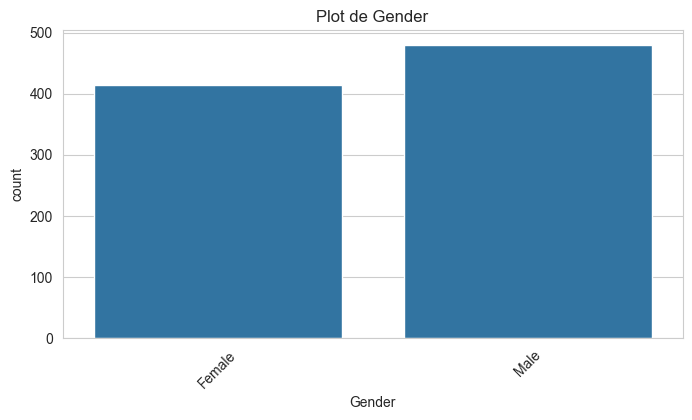

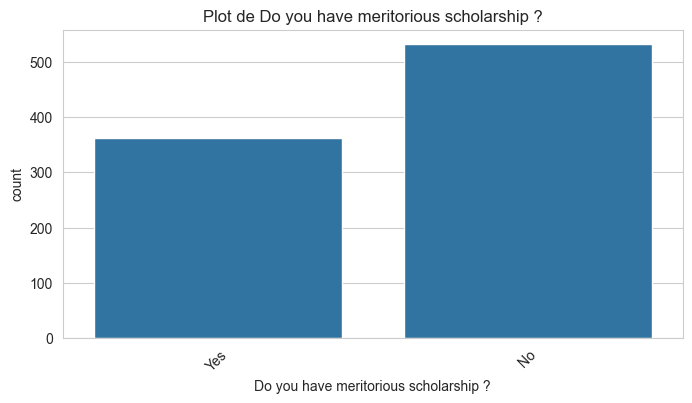

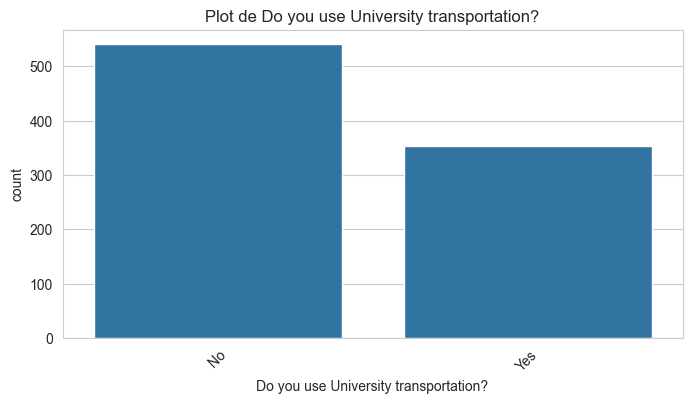

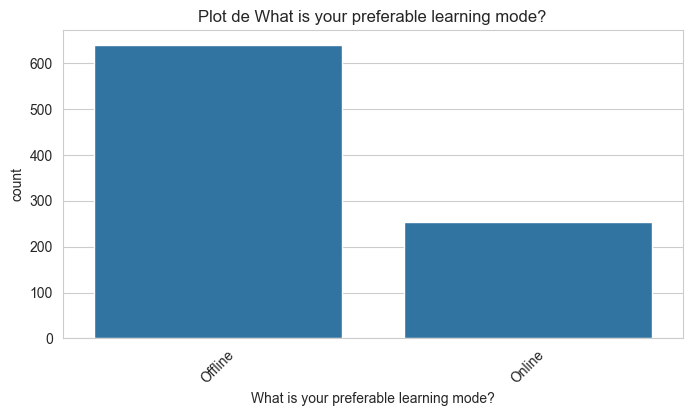

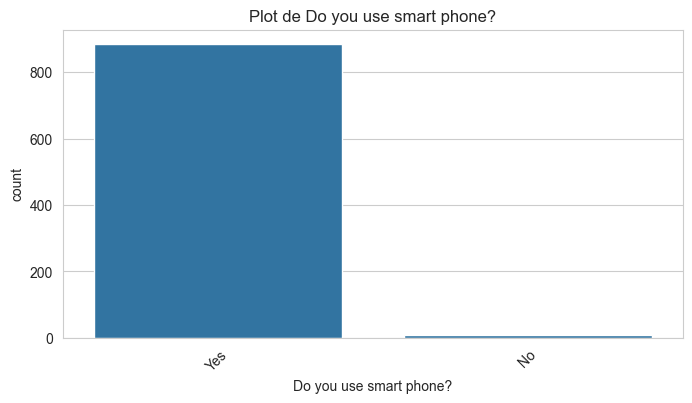

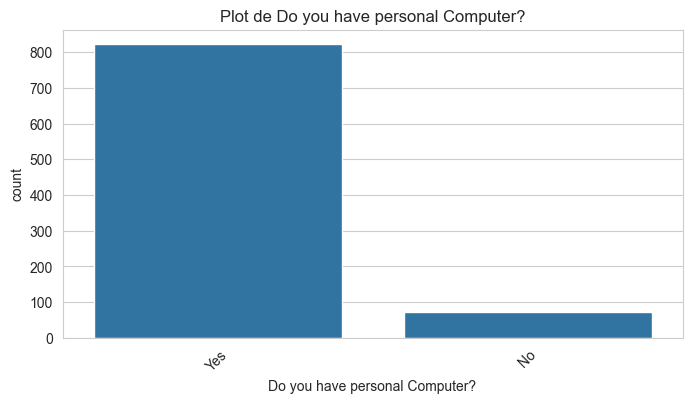

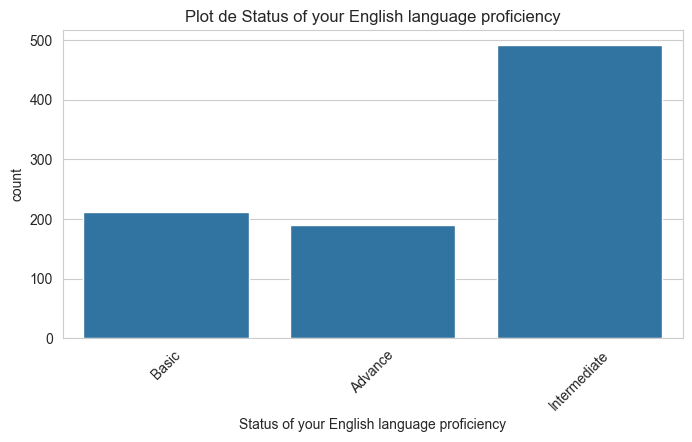

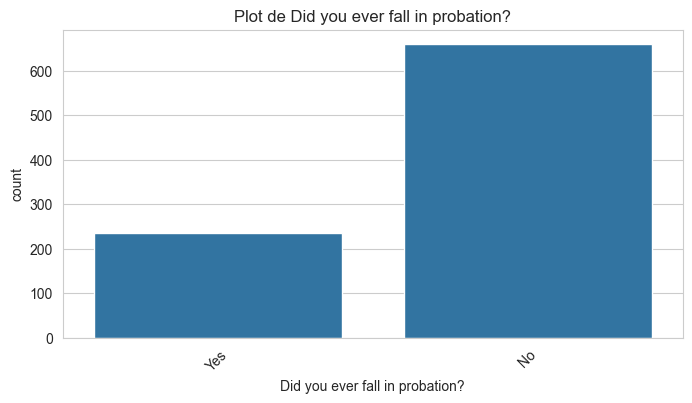

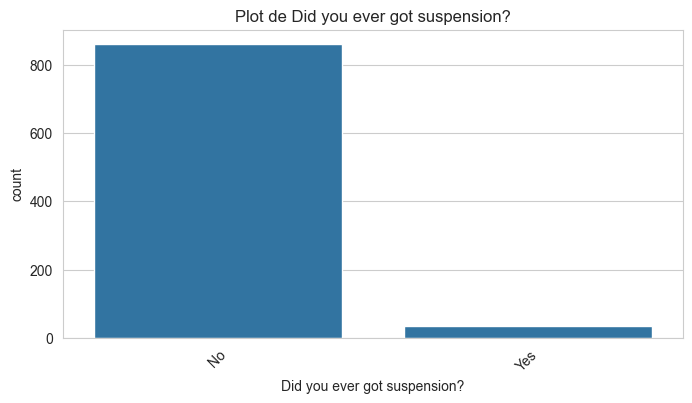

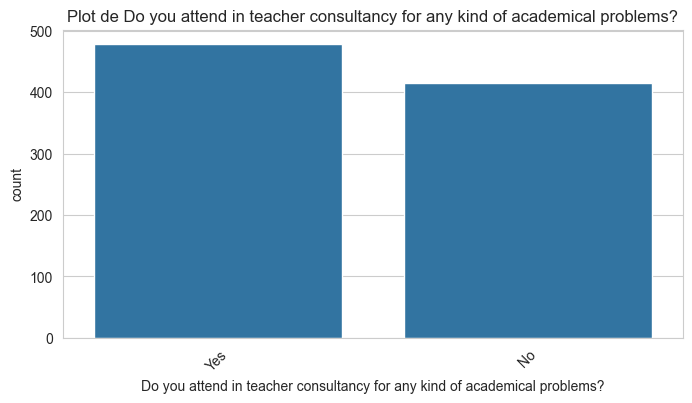

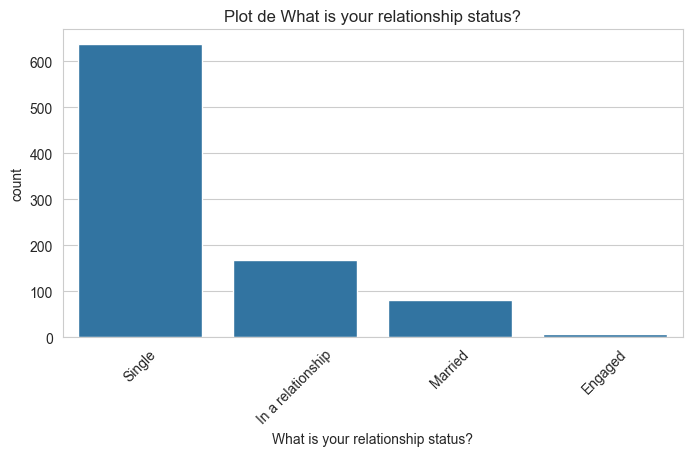

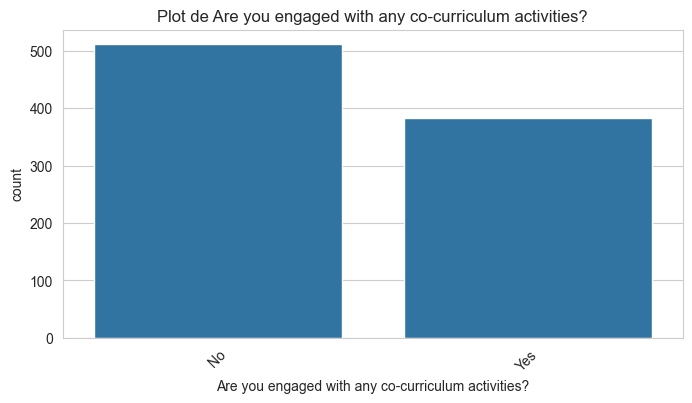

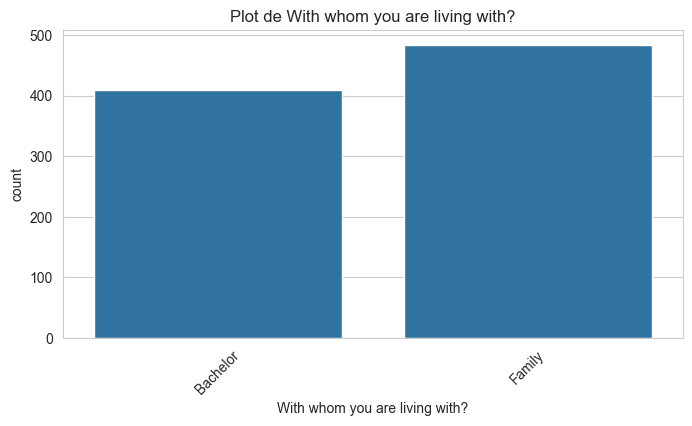

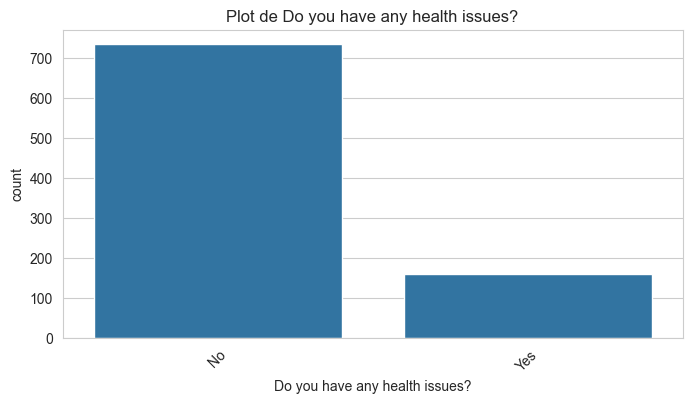

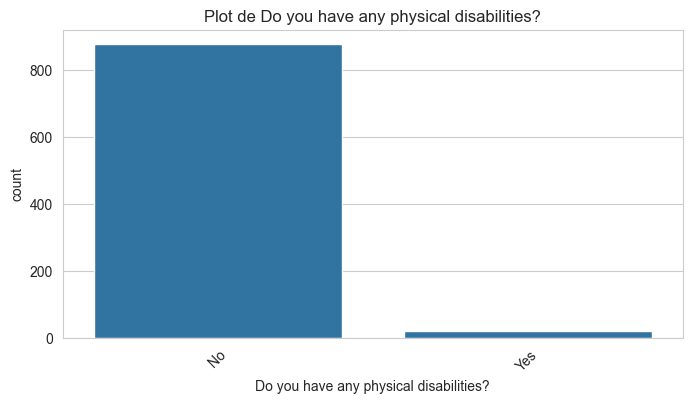

In [15]:
for var in Variables_mas_importante_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=var, data=df.dropna())
    plt.title(f"Plot de {var}")
    plt.xticks(rotation=45)
    plt.show()

# Correlación

Correlación de variables categóricas con CGPA:
Do you have meritorious scholarship ?                         0.1100
Do you have personal Computer?                                0.0552
With whom you are living with?                                0.0288
Are you engaged with any co-curriculum activities?            0.0016
Do you have any health issues?                               -0.0086
Do you use smart phone?                                      -0.0095
What is your preferable learning mode?                       -0.0106
Gender                                                       -0.0153
Do you attend in teacher consultancy for any kind of academical problems? -0.0216
What is your relationship status?                            -0.0222
Status of your English language proficiency                  -0.0299
Do you have any physical disabilities?                       -0.0436
Do you use University transportation?                        -0.0620
Did you ever got suspension?               

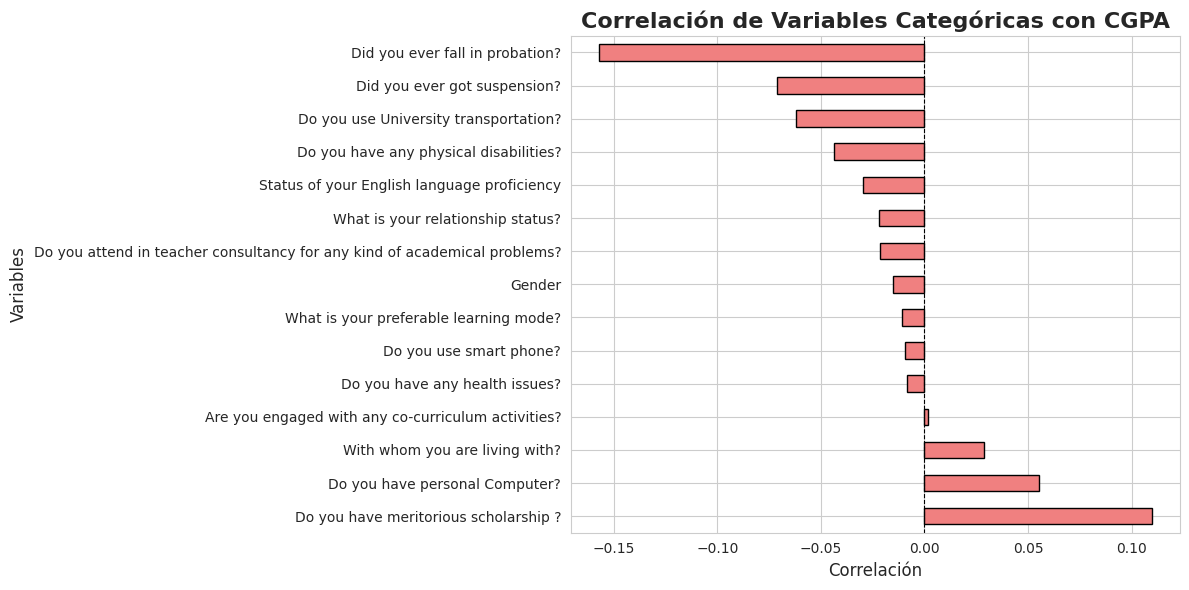

In [14]:
# Correlación entre CGPA y variables categóricas
from sklearn.preprocessing import LabelEncoder

target = "What is your current CGPA?"

# Crear copia del dataframe para no alterar el original
df_cat_corr = df[Variables_mas_importante_categoricas + [target]].copy()

# Eliminar filas con valores faltantes
df_cat_corr = df_cat_corr.dropna()

# Codificar variables categóricas
le_dict = {}
for col in Variables_mas_importante_categoricas:
    le = LabelEncoder()
    df_cat_corr[col + '_encoded'] = le.fit_transform(df_cat_corr[col])
    le_dict[col] = le

# Seleccionar solo columnas codificadas y el target
df_encoded = df_cat_corr[[col + '_encoded' for col in Variables_mas_importante_categoricas] + [target]]
df_encoded.columns = [col.replace('_encoded', '') for col in df_encoded.columns]

# Calcular correlación con CGPA
corr_cat = df_encoded.corr()[target].drop(target).sort_values(ascending=False)

print("Correlación de variables categóricas con CGPA:")
print("=" * 70)
for var, corr_val in corr_cat.items():
    print(f"{var:60} {corr_val:7.4f}")

# Grafico
plt.figure(figsize=(12, 6))
corr_cat.plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title('Correlación de Variables Categóricas con CGPA', fontsize=16, fontweight='bold')
plt.xlabel('Correlación', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


## BoxPlots


Boxplots de CGPA por categoría:


<Figure size 1200x700 with 0 Axes>

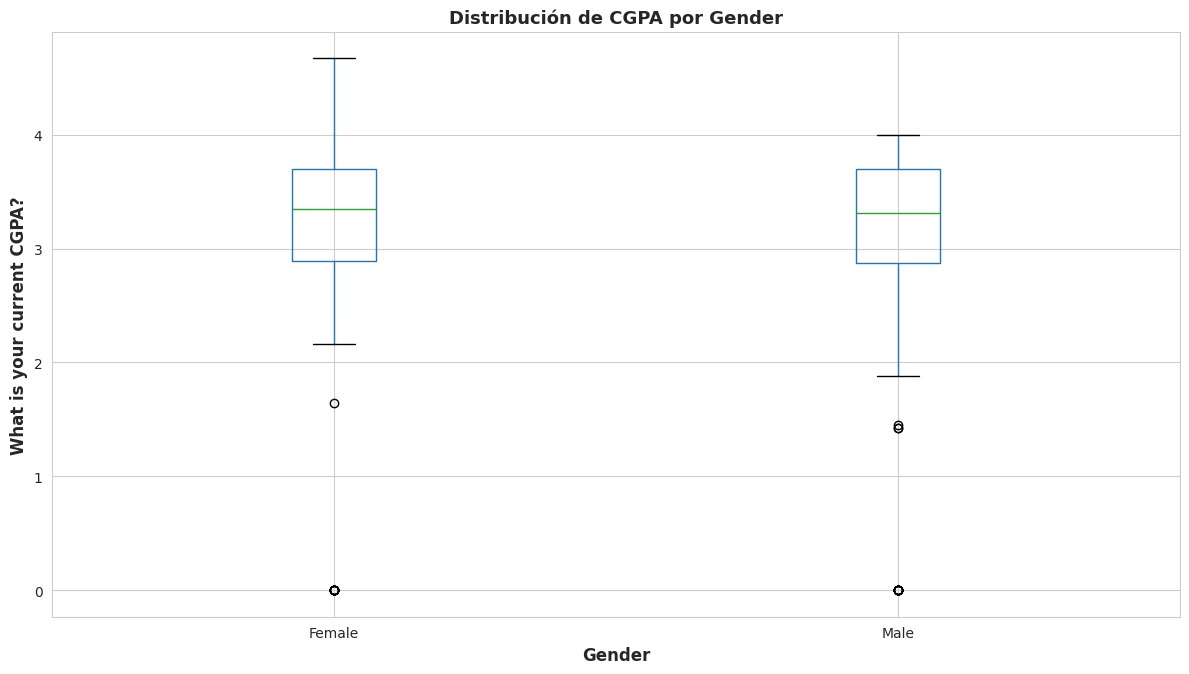

<Figure size 1200x700 with 0 Axes>

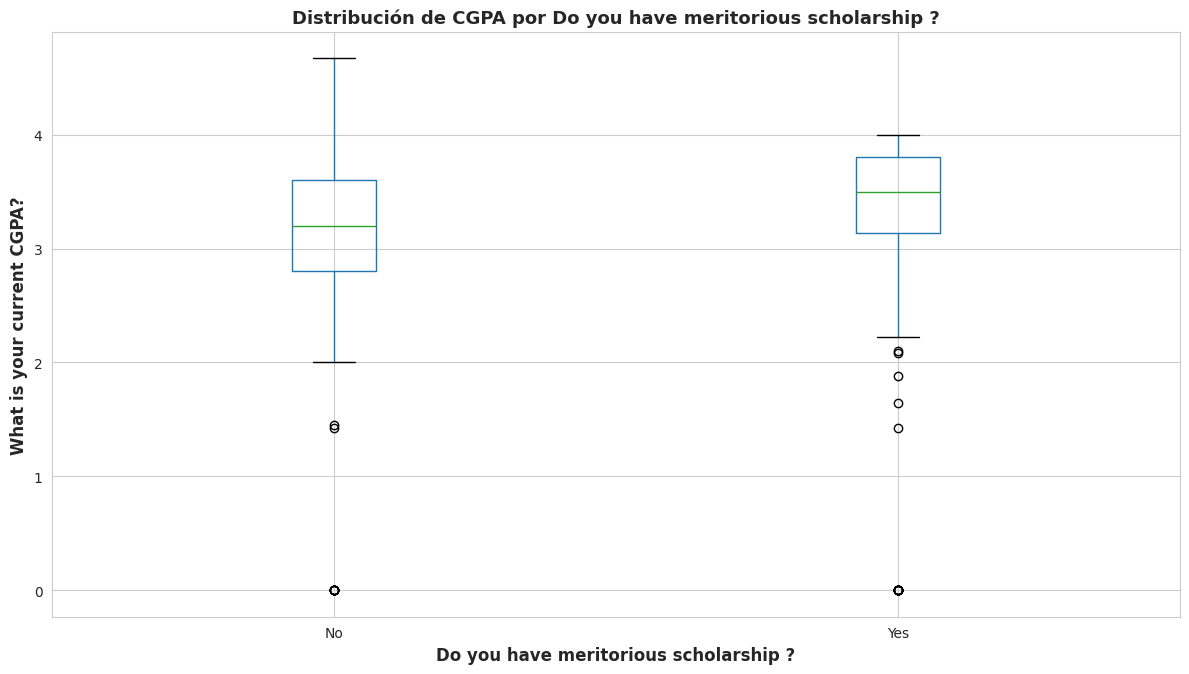

<Figure size 1200x700 with 0 Axes>

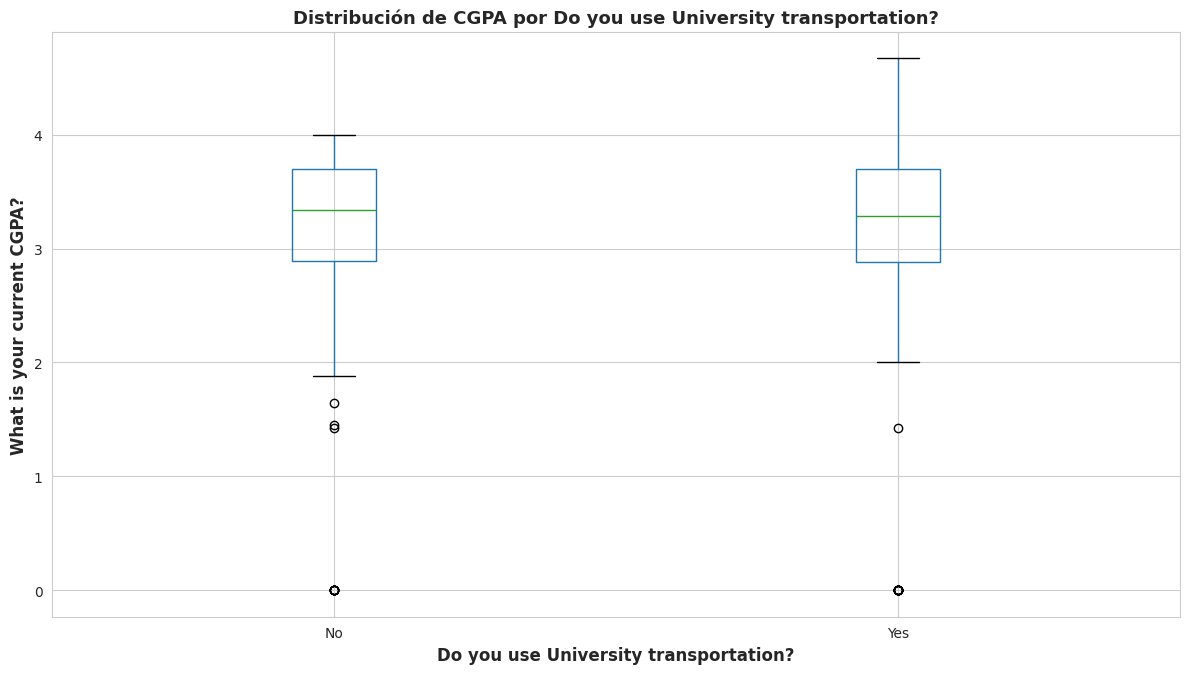

<Figure size 1200x700 with 0 Axes>

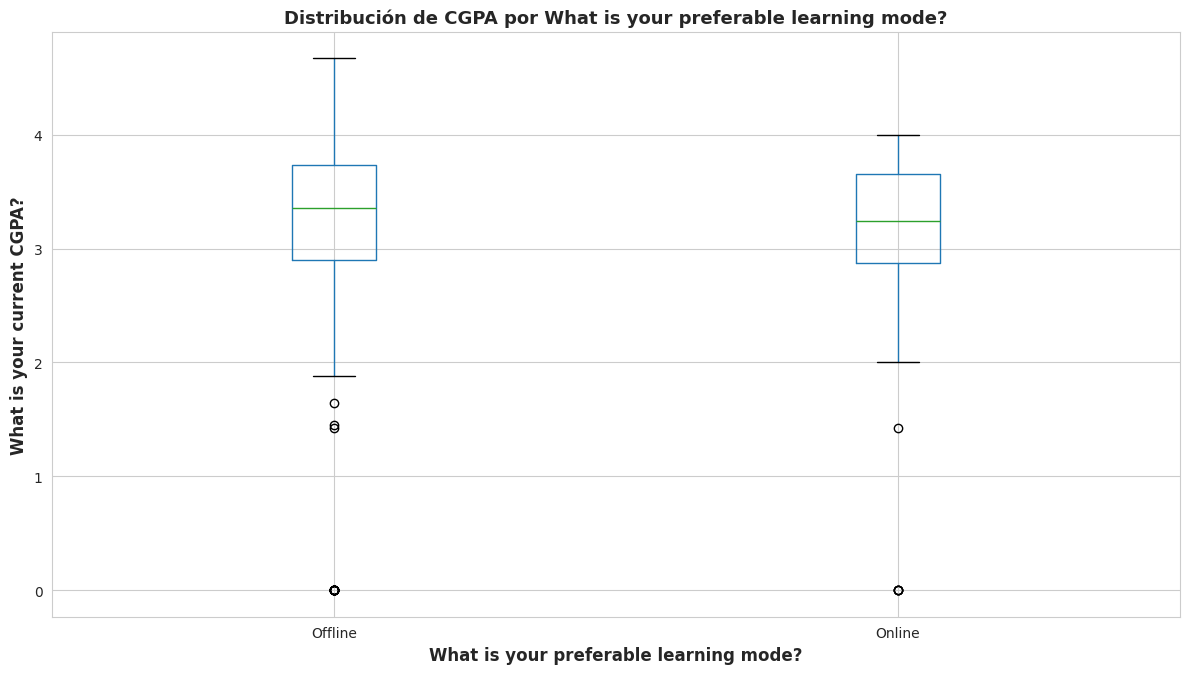

<Figure size 1200x700 with 0 Axes>

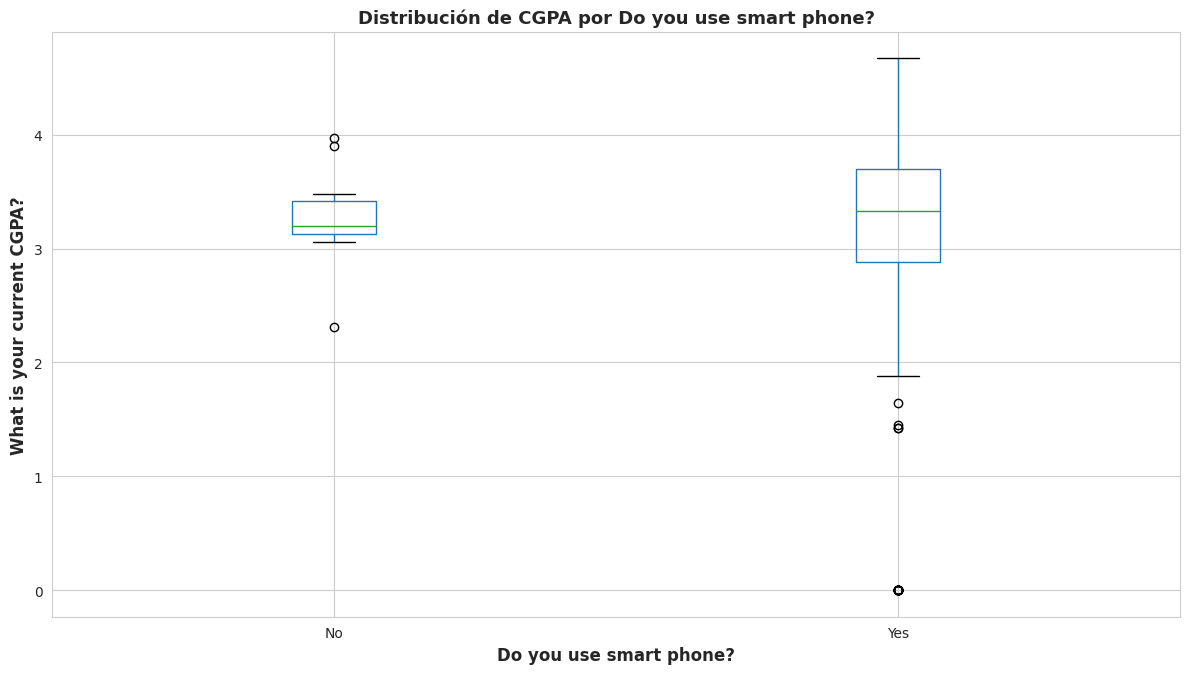

<Figure size 1200x700 with 0 Axes>

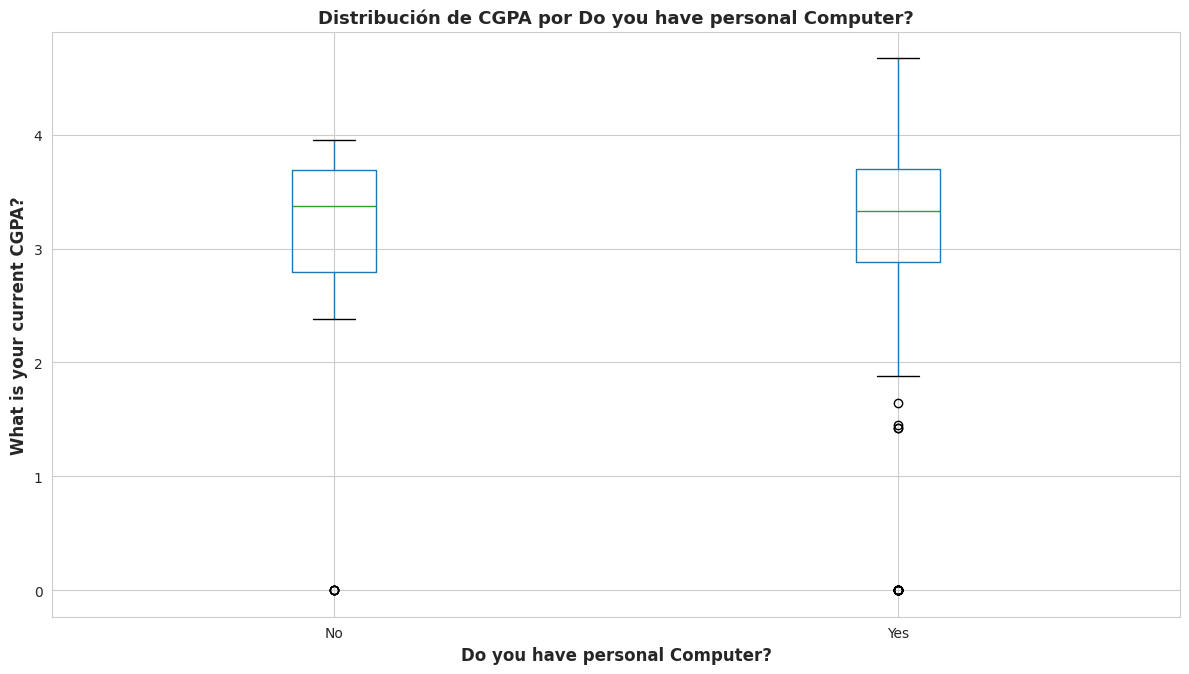

<Figure size 1200x700 with 0 Axes>

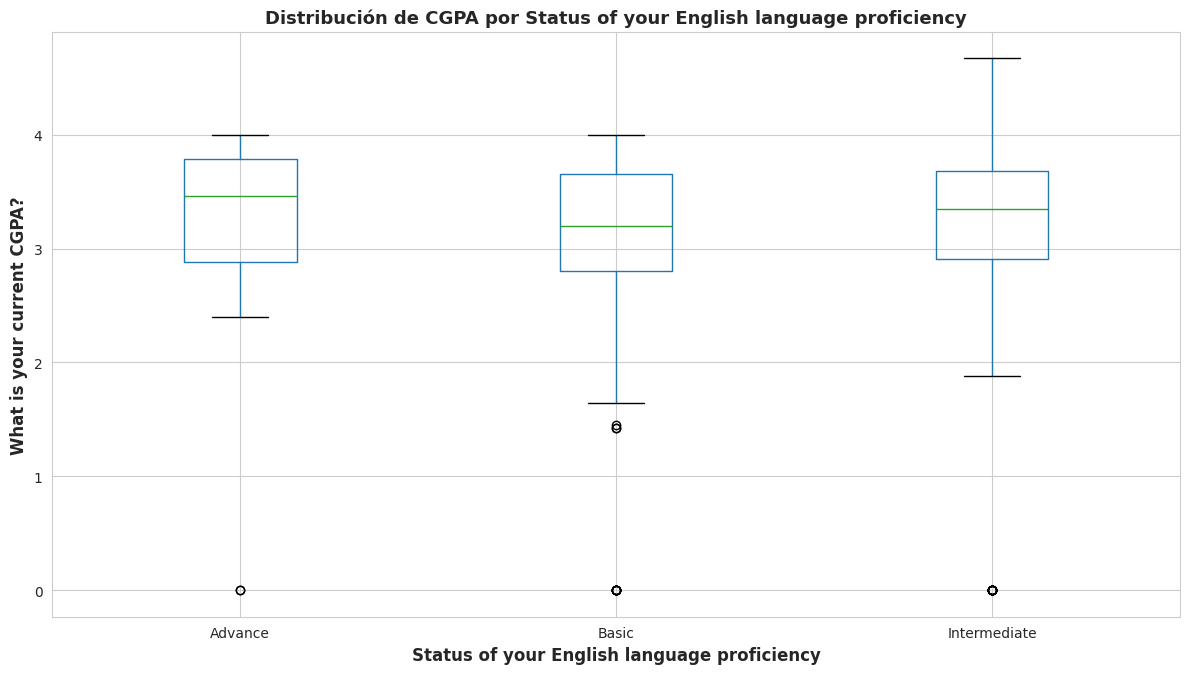

<Figure size 1200x700 with 0 Axes>

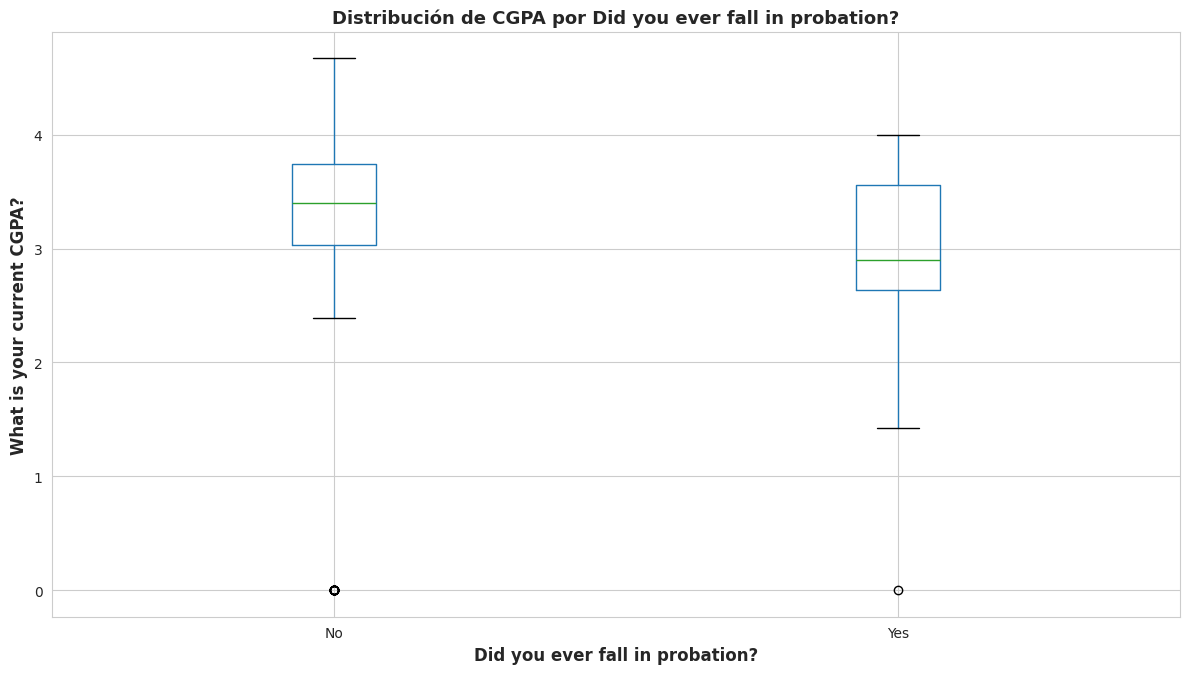

<Figure size 1200x700 with 0 Axes>

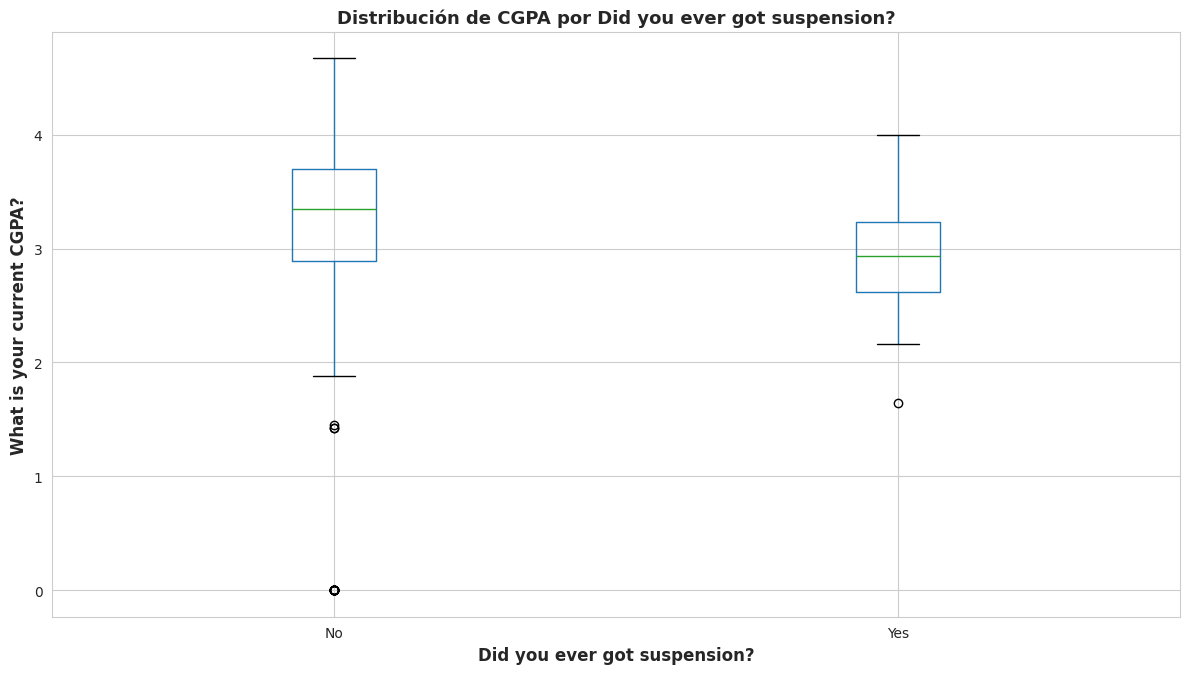

<Figure size 1200x700 with 0 Axes>

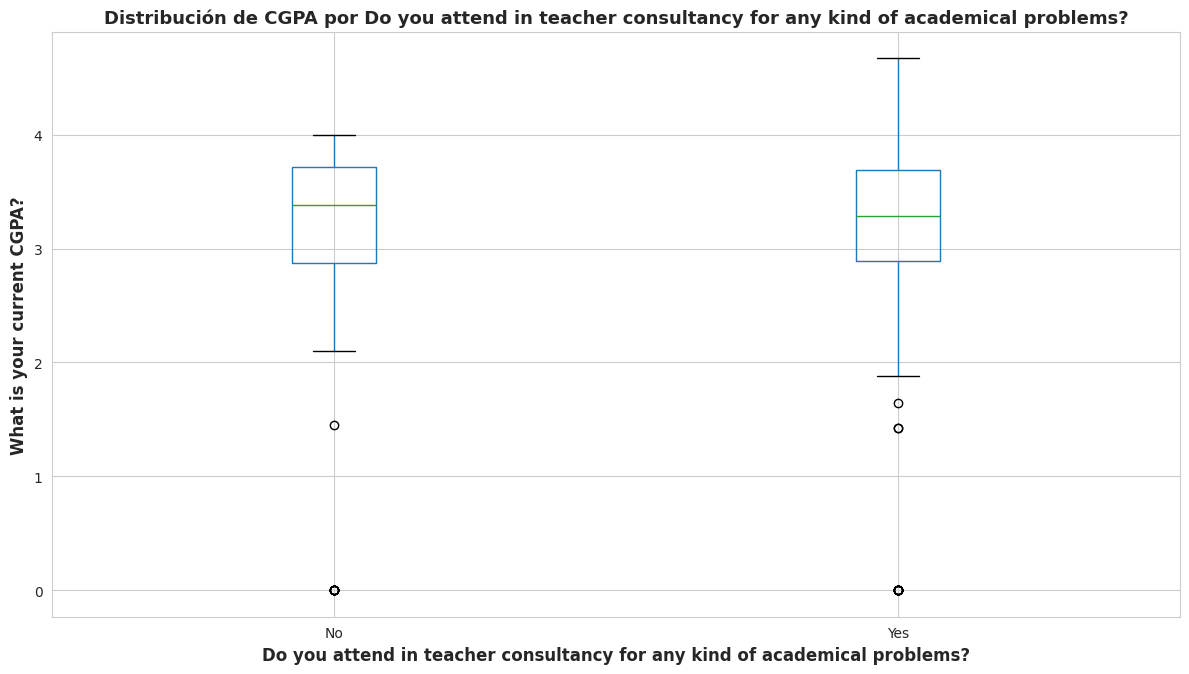

<Figure size 1200x700 with 0 Axes>

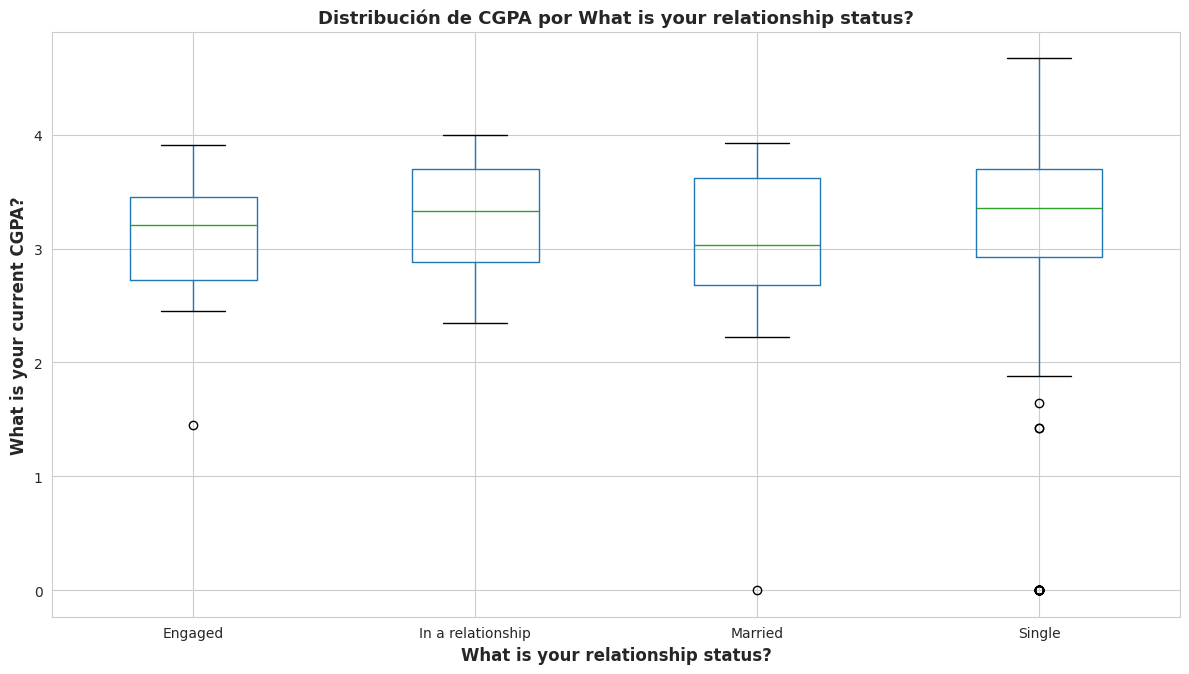

<Figure size 1200x700 with 0 Axes>

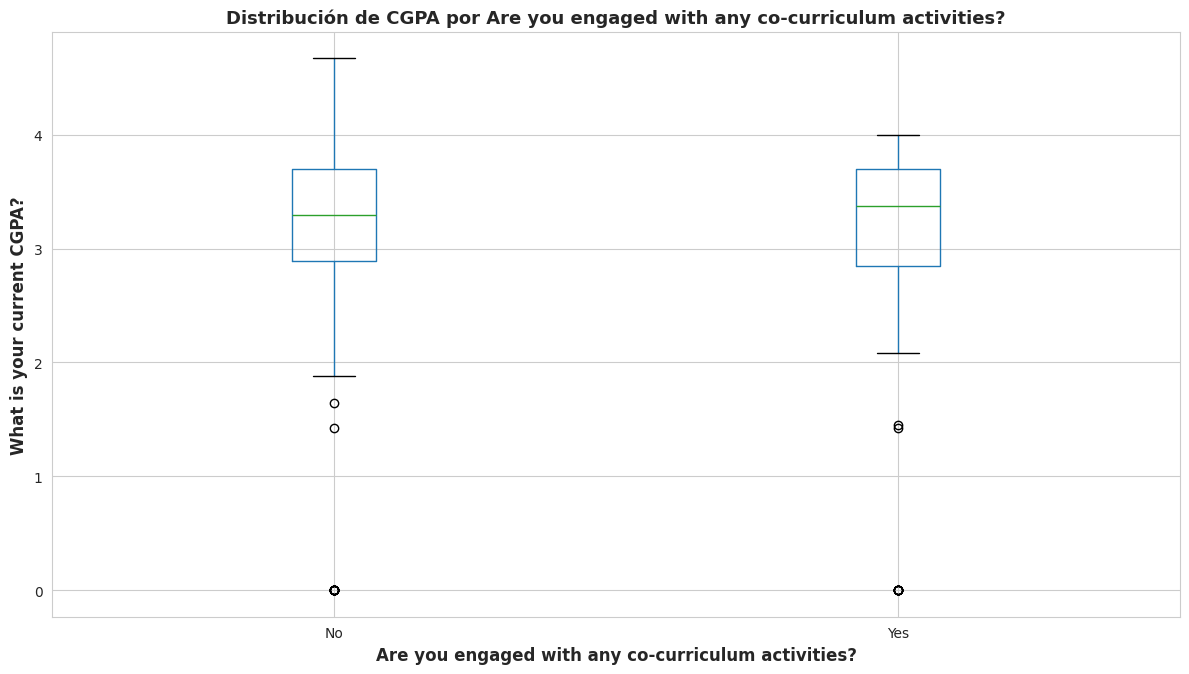

<Figure size 1200x700 with 0 Axes>

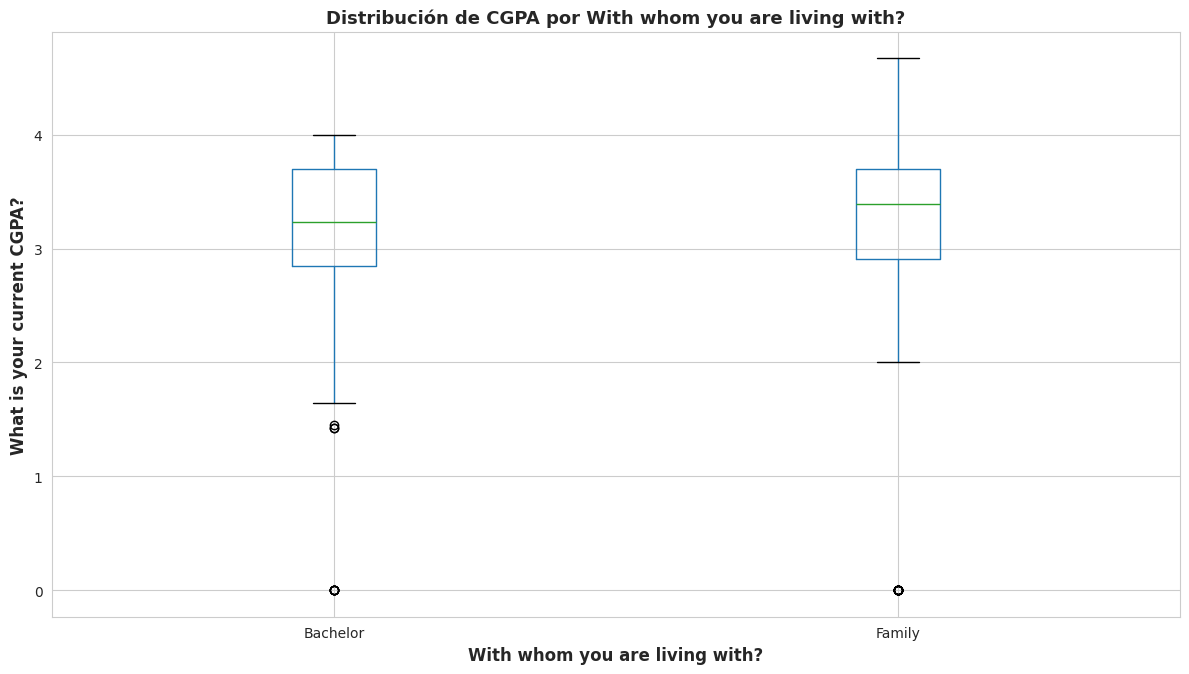

<Figure size 1200x700 with 0 Axes>

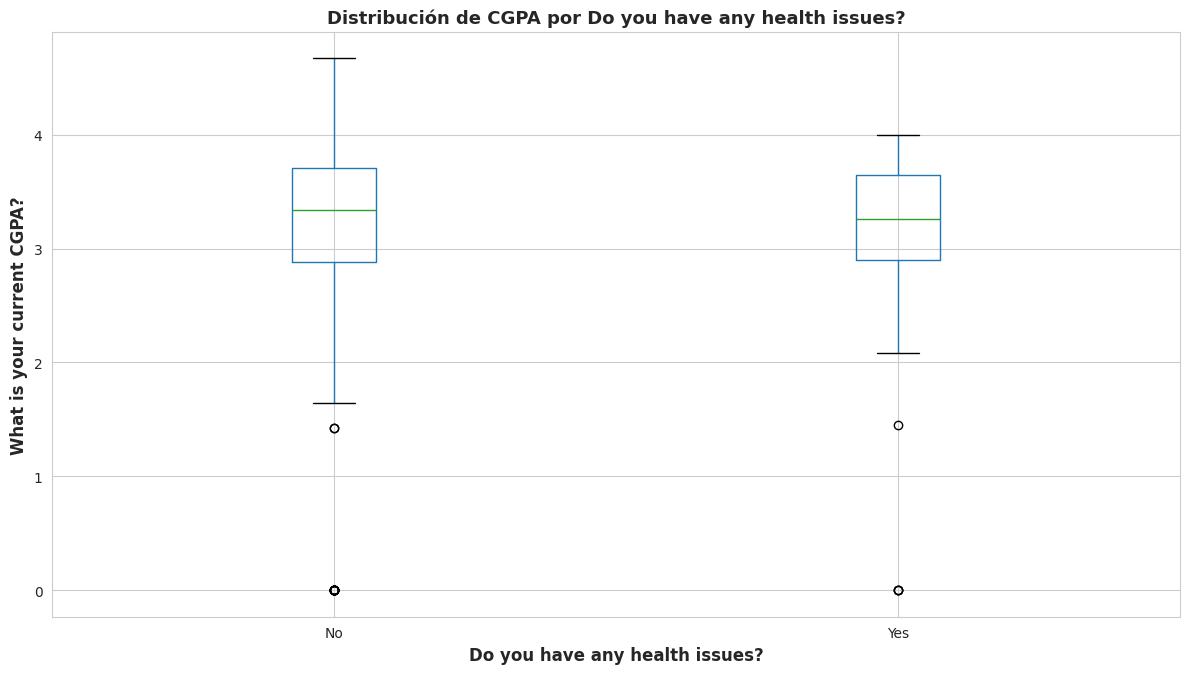

<Figure size 1200x700 with 0 Axes>

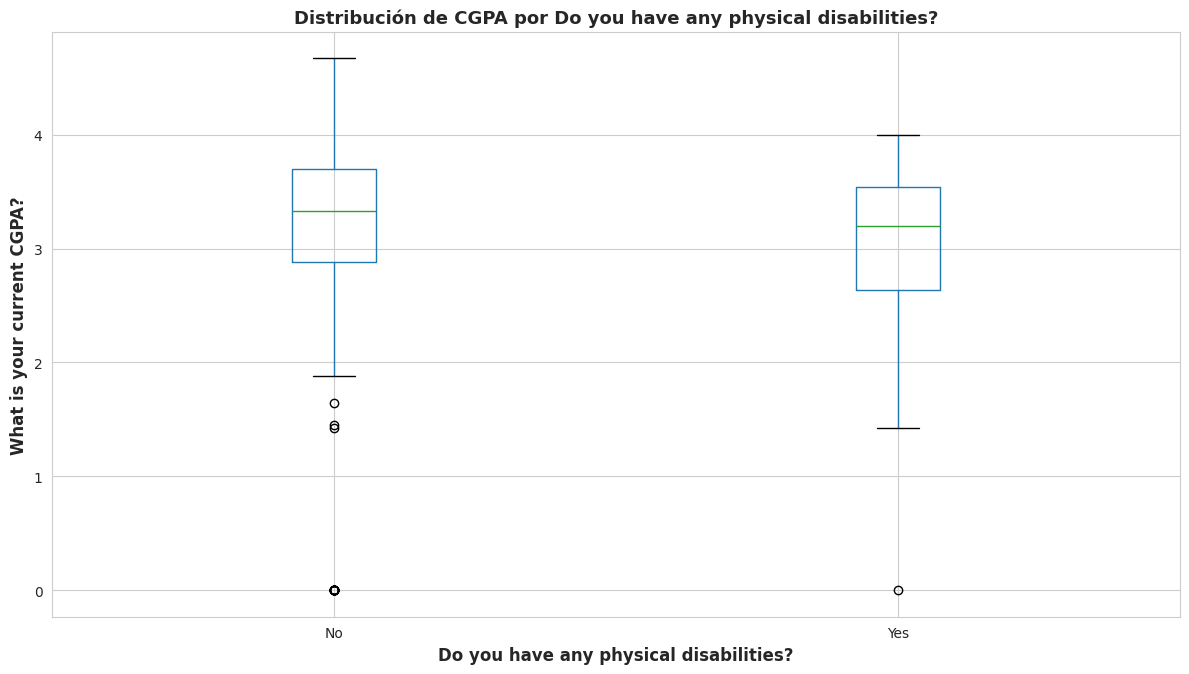

In [15]:
# Análisis de relación entre variables - Scatter plots

target = "What is your current CGPA?"

# Gráficos de boxplot para visualizar la relación
print("\nBoxplots de CGPA por categoría:")
for var in Variables_mas_importante_categoricas:
    try:
        temp_df = df[[var, target]].dropna()
        
        if len(temp_df) > 0:
            plt.figure(figsize=(12, 7))
            temp_df.boxplot(column=target, by=var, figsize=(12, 7))
            plt.suptitle('')
            plt.xlabel(var, fontsize=12, fontweight='bold')
            plt.ylabel(target, fontsize=12, fontweight='bold')
            plt.title(f'Distribución de CGPA por {var}', fontsize=13, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Sin datos válidos para {var}")
    except Exception as e:
        print(f"  Error en {var}: {e}")

# 4. Análisis de variables numericas

# Análisis descriptivo

In [16]:
def Describir_numericas(df, Variables_mas_importante):
    numericas = indentificar_tipos_de_variables(df)[1]
    for var in Variables_mas_importante_numericas:
        print(f"===================================================================================")
        print(f"Análisis {var}")
        print(f"===================================================================================")
        print(f"-Promedio: {df[var].mean()}")
        print(f"-Mediana: {df[var].median()}")
        print(f"-Varianza: {df[var].var()}")
        print(f"-Cuantiles: {df[var].quantile([0.25,0.5,0.75])}")

Describir_numericas(df, Variables_mas_importante_numericas )

Análisis University Admission year
-Promedio: 2020.5123042505593
-Mediana: 2021.0
-Varianza: 1.670061201840815
-Cuantiles: 0.25    2020.00
0.50    2021.00
0.75    2021.75
Name: University Admission year, dtype: float64
Análisis Age (Years)
-Promedio: 21.354586129753915
-Mediana: 21.0
-Varianza: 2.571776256291163
-Cuantiles: 0.25    20.0
0.50    21.0
0.75    22.0
Name: Age (Years), dtype: float64
Análisis H.S.C passing year
-Promedio: 2019.2665173572227
-Mediana: 2020.0
-Varianza: 1.7162025408521424
-Cuantiles: 0.25    2019.0
0.50    2020.0
0.75    2020.0
Name: H.S.C passing year, dtype: float64
Análisis Current Semester
-Promedio: 6.442953020134228
-Mediana: 7.0
-Varianza: 11.38028063160901
-Cuantiles: 0.25    3.0
0.50    7.0
0.75    9.0
Name: Current Semester, dtype: float64
Análisis How many hour do you study daily? (Hours )
-Promedio: 3.2293064876957494
-Mediana: 3.0
-Varianza: 4.356094255344201
-Cuantiles: 0.25    2.0
0.50    3.0
0.75    4.0
Name: How many hour do you study daily? 

# Valores atípicos

In [17]:
# Dedectar valor atípicos
def detectar_outliers(df, variable):
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)]
    return outliers

for Variable in Variables_mas_importante_numericas:
    print(f"===================================================================================")
    print(f"Análisis de outliers para {Variable}")
    print(f"===================================================================================")
    outliers = detectar_outliers(df, Variable)
    print(f"-Número de outliers: {len(outliers)}")
    print(f"-Valores atípicos:\n{outliers[Variable].tolist()}")

Análisis de outliers para University Admission year
-Número de outliers: 13
-Valores atípicos:
[2017, 2014, 2017, 2017, 2017, 2017, 2016, 2016, 2017, 2014, 2017, 2013, 2014]
Análisis de outliers para Age (Years)
-Número de outliers: 6
-Valores atípicos:
[26, 26, 26, 26, 26, 26]
Análisis de outliers para H.S.C passing year
-Número de outliers: 85
-Valores atípicos:
[2016.0, 2017.0, 2017.0, 2017.0, 2016.0, 2016.0, 2017.0, 2014.0, 2017.0, 2015.0, 2017.0, 2017.0, 2017.0, 2017.0, 2016.0, 2017.0, 2016.0, 2014.0, 2017.0, 2014.0, 2017.0, 2017.0, 2017.0, 2016.0, 2017.0, 2017.0, 2017.0, 2017.0, 2015.0, 2017.0, 2016.0, 2016.0, 2017.0, 2017.0, 2016.0, 2014.0, 2017.0, 2016.0, 2017.0, 2014.0, 2016.0, 2017.0, 2016.0, 2017.0, 2016.0, 2017.0, 2017.0, 2017.0, 2016.0, 2017.0, 2013.0, 2017.0, 2016.0, 2017.0, 2017.0, 2017.0, 2017.0, 2012.0, 2017.0, 2017.0, 2013.0, 2016.0, 2017.0, 2016.0, 2017.0, 2017.0, 2016.0, 2017.0, 2017.0, 2017.0, 2022.0, 2022.0, 2017.0, 2022.0, 2017.0, 2022.0, 2017.0, 2022.0, 2017.0, 

# Histogramas


In [18]:
def crear_histogramas_sin_outliers(df, columna, bins=None, color="skyblue", titulo=None, clip_outliers=True):
    data = df[columna].dropna()

    # Calcular límites de outliers con IQR
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    data_sin_outliers = data[(data >= lower_bound) & (data <= upper_bound)]
    n_outliers = len(data) - len(data_sin_outliers)

    if clip_outliers and len(data_sin_outliers) >= max(3, len(data) * 0.5):
        data_plot = data_sin_outliers
        rango_text = f"(sin outliers: {lower_bound:.2f} a {upper_bound:.2f})"
    else:
        data_plot = data
        rango_text = "(incluye todos los valores)"

    # Calcular bins óptimos si no se especifican
    if bins is None:
        if data_plot.nunique() <= 20:
            bins = data_plot.nunique()
        else:
            q75p, q25p = np.percentile(data_plot, [75, 25])
            iqrp = q75p - q25p
            if iqrp > 0:
                bin_width = 2 * iqrp / (len(data_plot) ** (1/3))
                bins = int(np.ceil((data_plot.max() - data_plot.min()) / bin_width))
                bins = max(15, min(bins, 40))
            else:
                bins = 20

    # Crear figura y eje
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('white')

    # Histograma
    ax.hist(data_plot, bins=bins, color=color, edgecolor='black', alpha=0.85)

    # Títulos
    if titulo is None:
        titulo = f"Distribución de {columna} {rango_text}"
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel(columna, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)

    # Estadística descriptiva
    Mediana = data.median()
    Promedio = data.mean()
    Varianza = data.var()

    # Líneas de estadística descriptiva
    ax.axvline(Mediana, color='red', linestyle='dashed', linewidth=1.5, label=f'Mediana: {Mediana:.2f}')
    ax.axvline(Promedio, color='green', linestyle='dashed', linewidth=1.5, label=f'Promedio: {Promedio:.2f}')
    ax.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10)

    # Información estadística en el gráfico
    stats_text = (
        f'n = {len(data)}\n'
        f'Media = {Promedio:.2f}\n'
        f'Mediana = {Mediana:.2f}\n'
        f'Varianza = {Varianza:.2f}\n'
        f'Rango datos = {data.min():.2f} - {data.max():.2f}\n'
        f'Valores usados = {len(data_plot)} ({n_outliers} outliers excluidos)'
    )
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#cccccc'), fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

Todas las columnas están presentes. Generando histogramas...

Generando histograma para: University Admission year


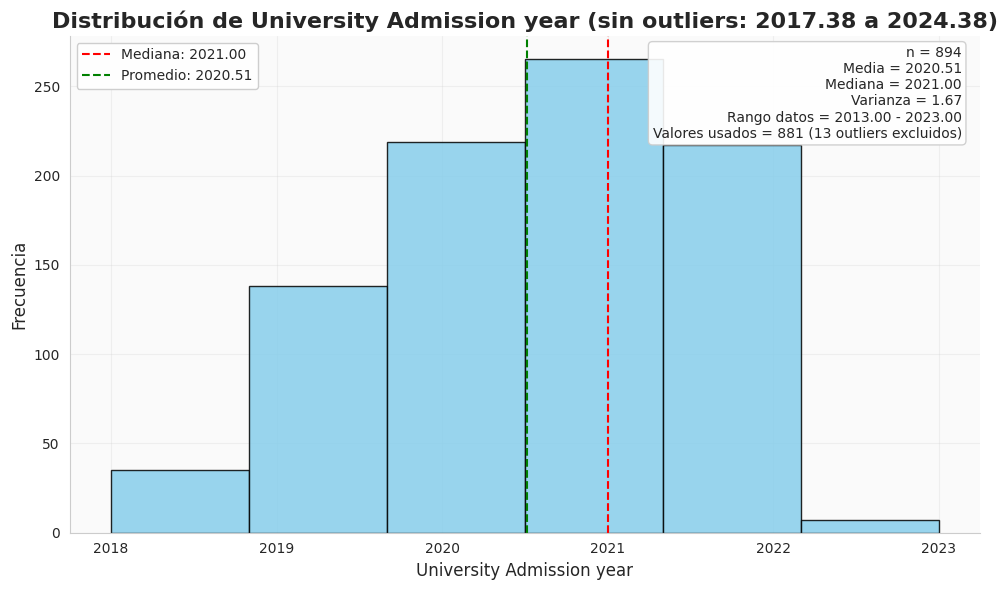


Generando histograma para: Age (Years)


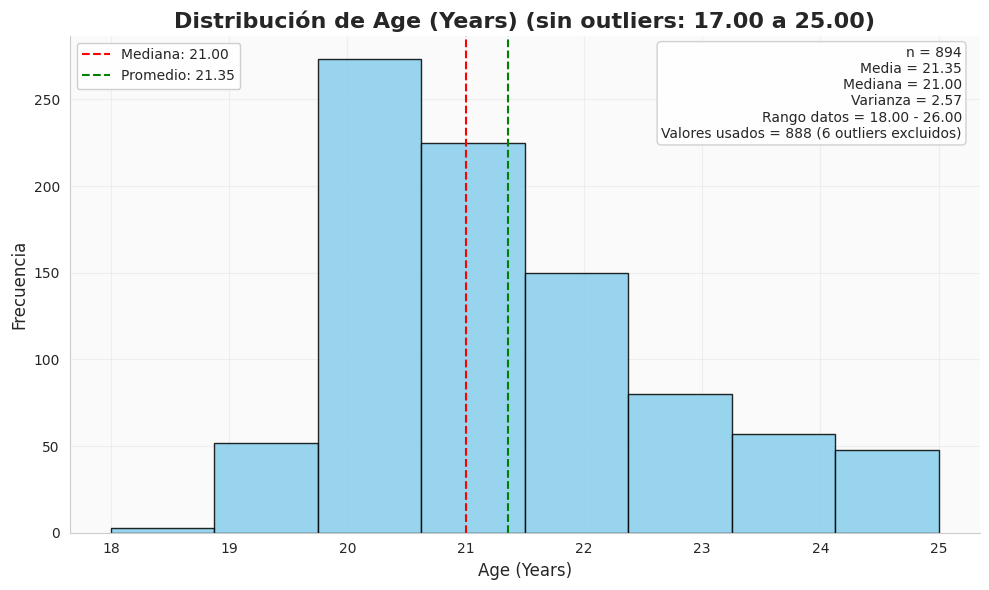


Generando histograma para: H.S.C passing year


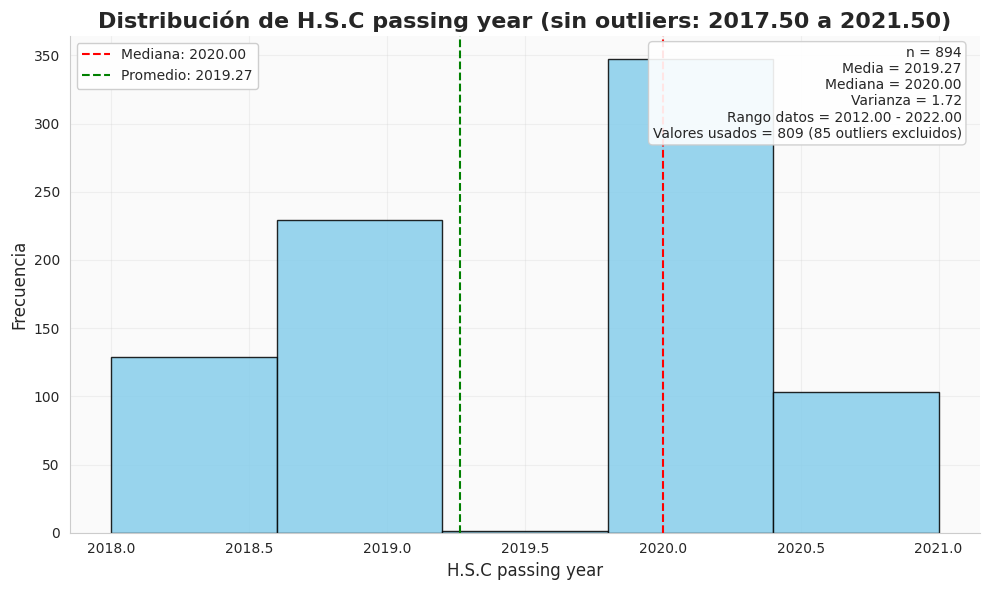


Generando histograma para: Current Semester


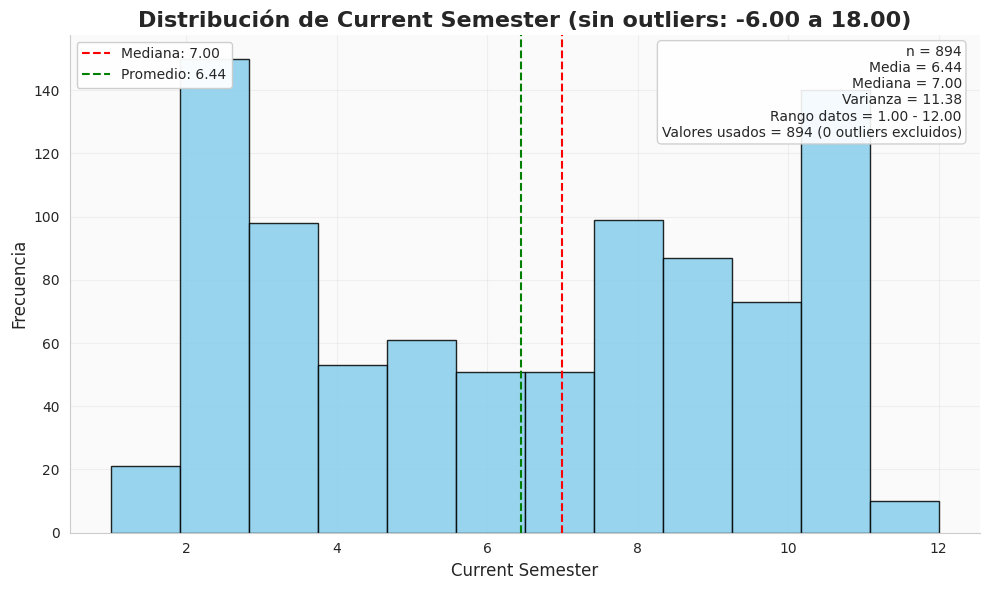


Generando histograma para: How many hour do you study daily? (Hours )


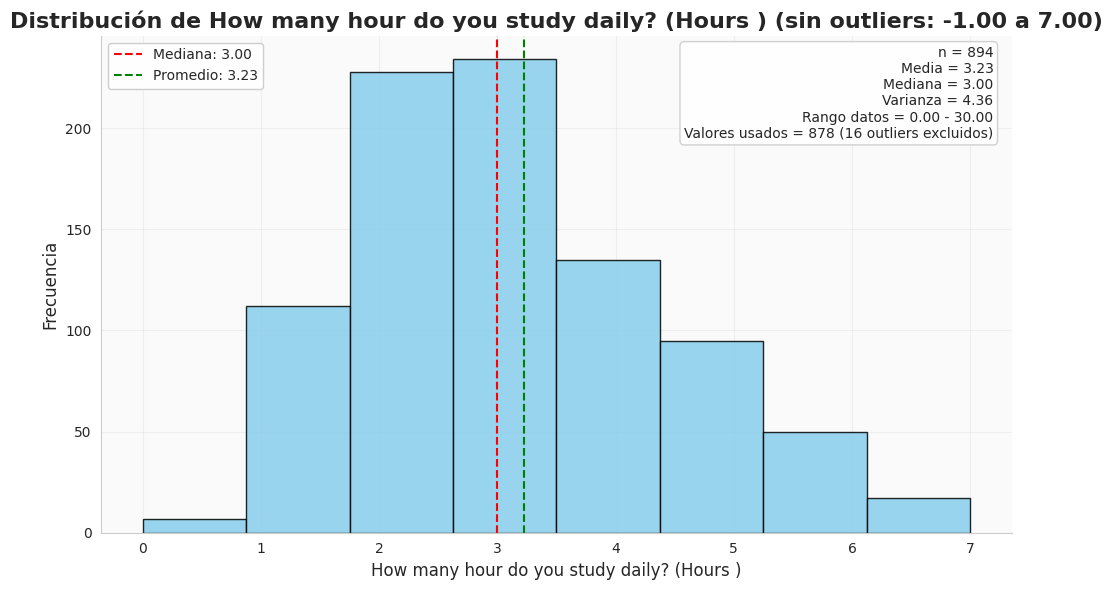


Generando histograma para: How many times do you seat for study in a day?


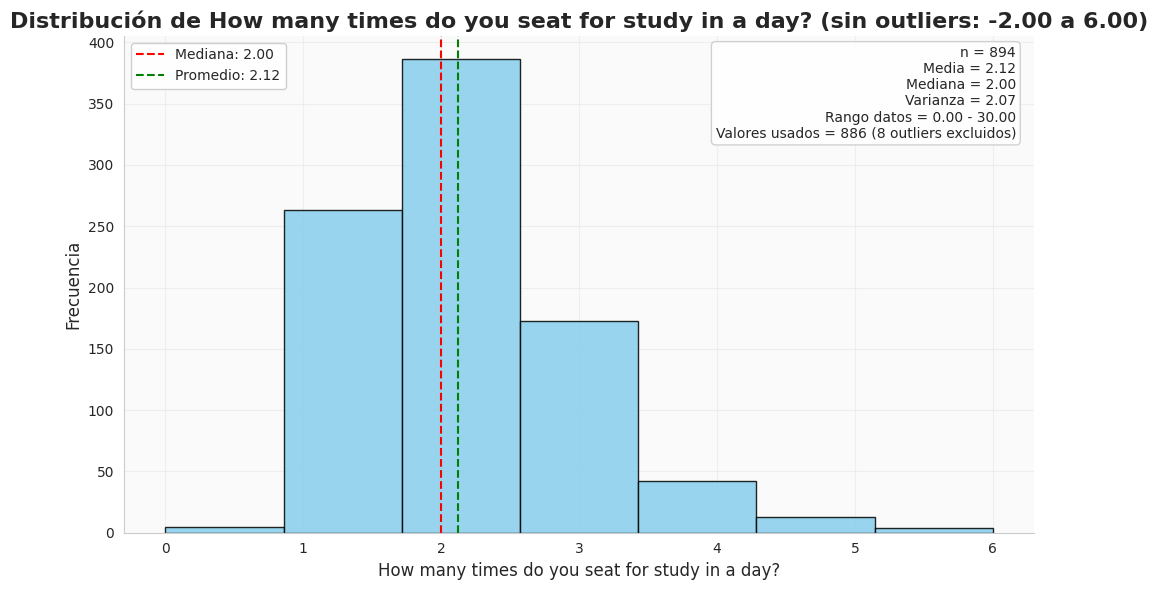


Generando histograma para: How many hour do you spent daily in social media? (Hours)


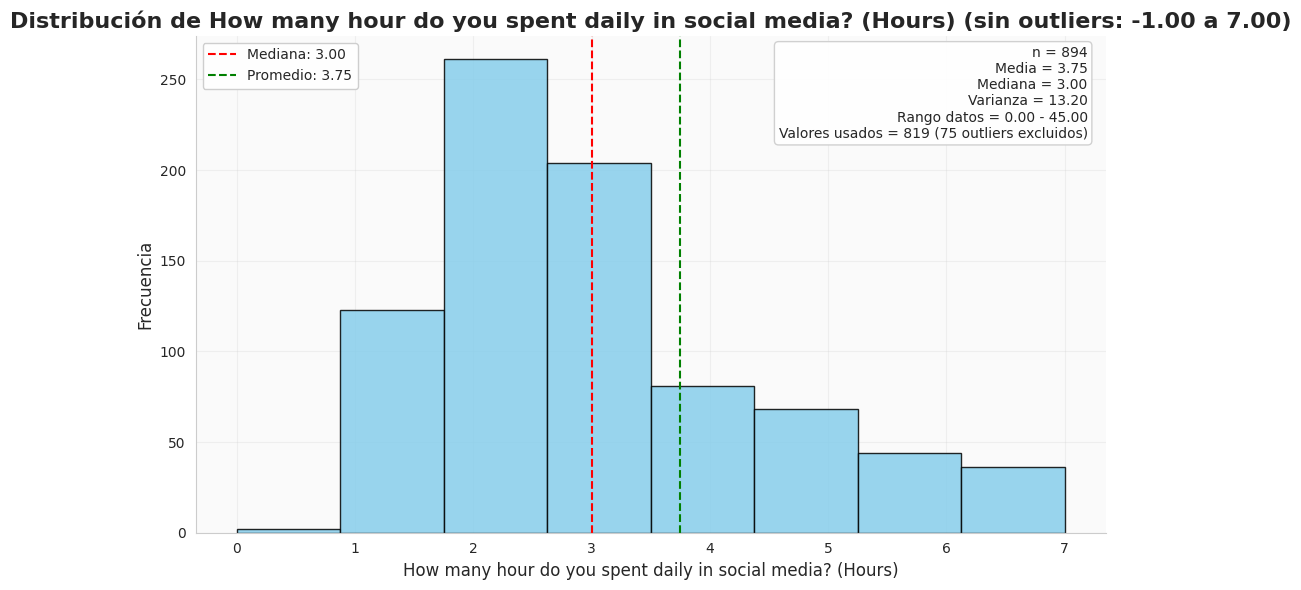


Generando histograma para: Average attendance on class (Percentage )


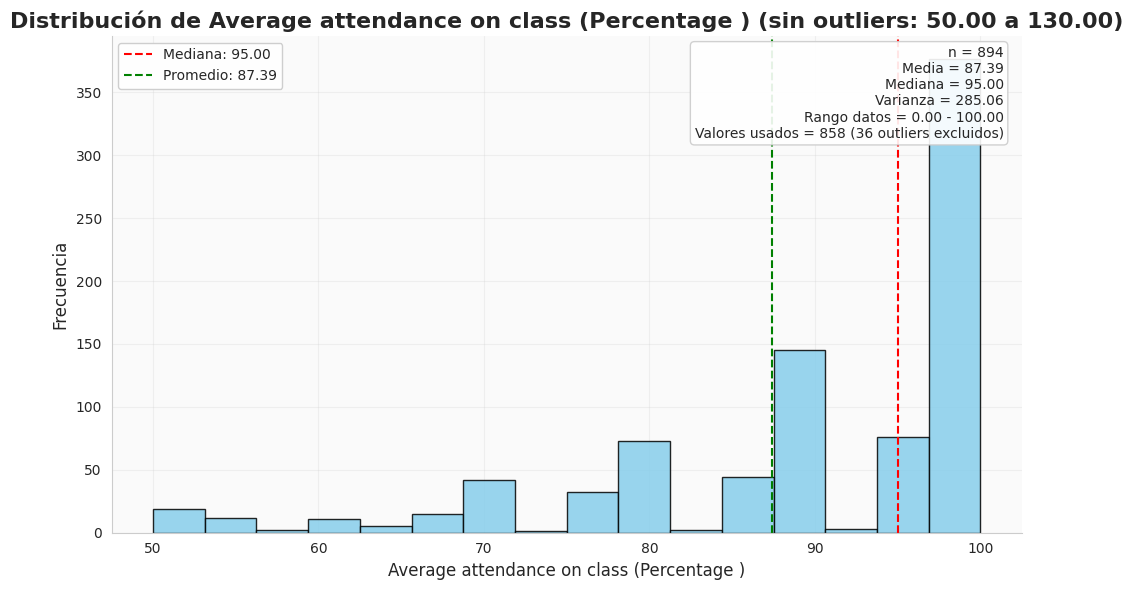


Generando histograma para: How many hour do you spent daily on your skill development? (Hours )


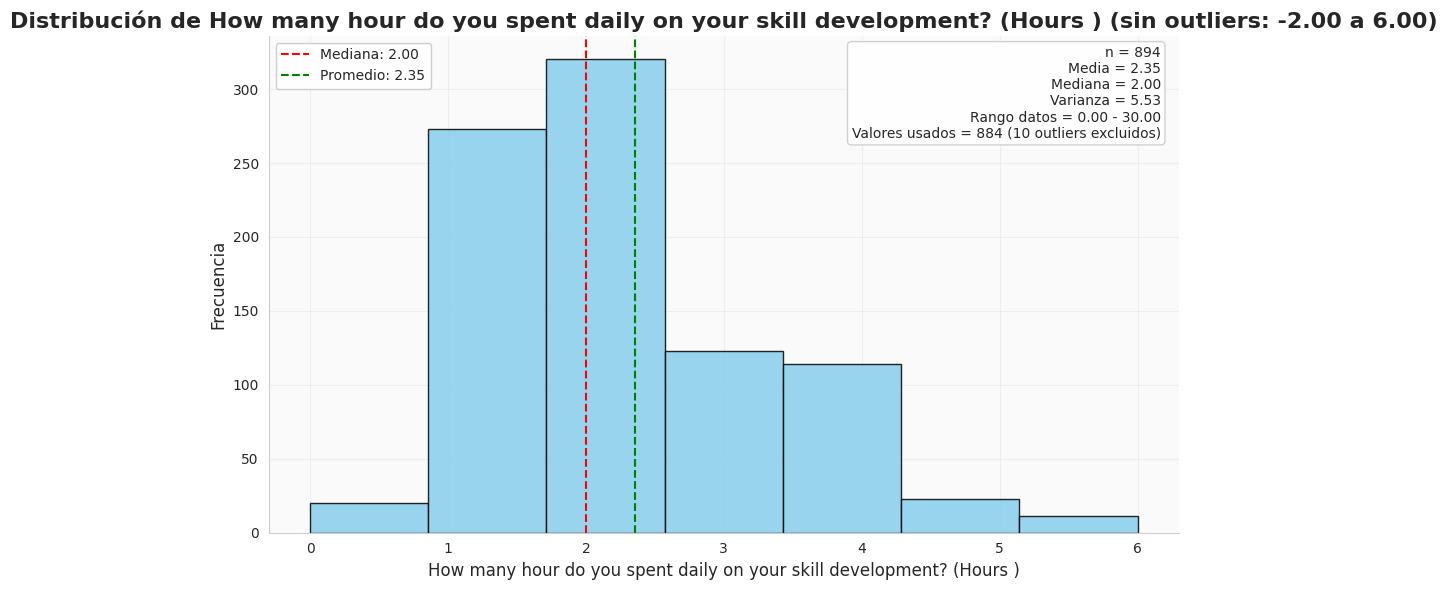


Generando histograma para: What was your previous SGPA?


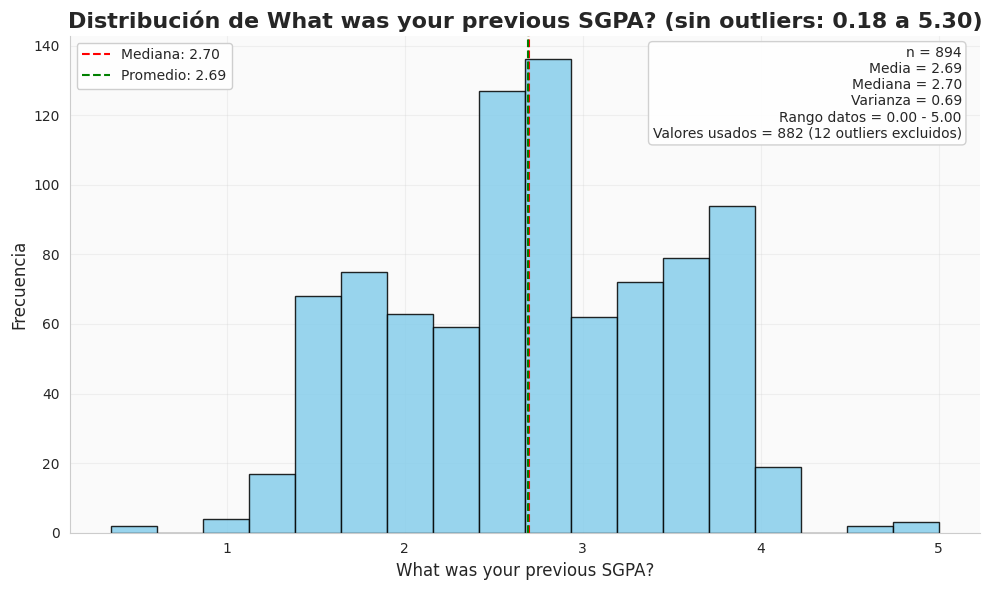


Generando histograma para: What is your current CGPA?


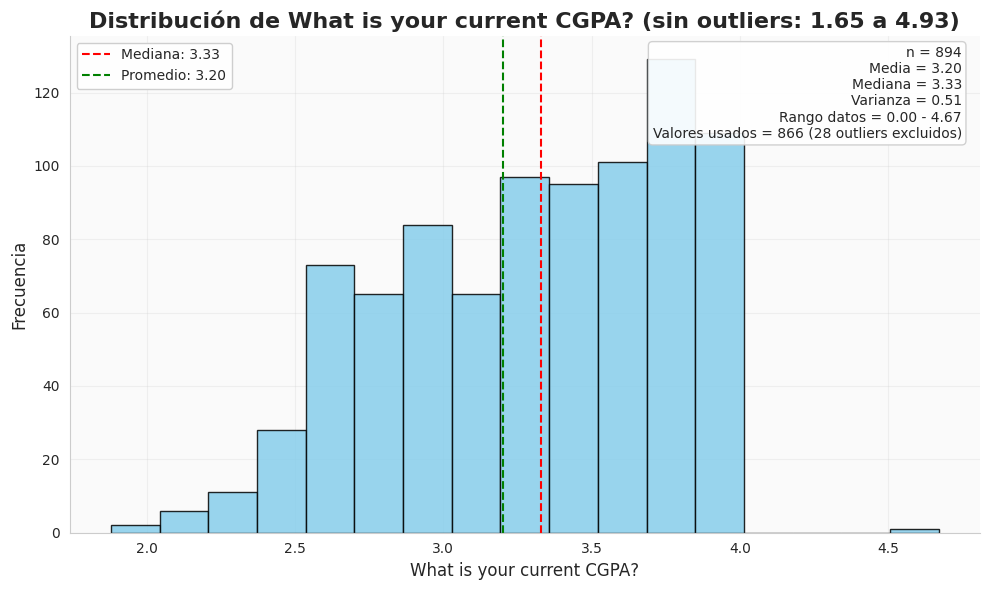


Generando histograma para: How many Credit did you have completed?


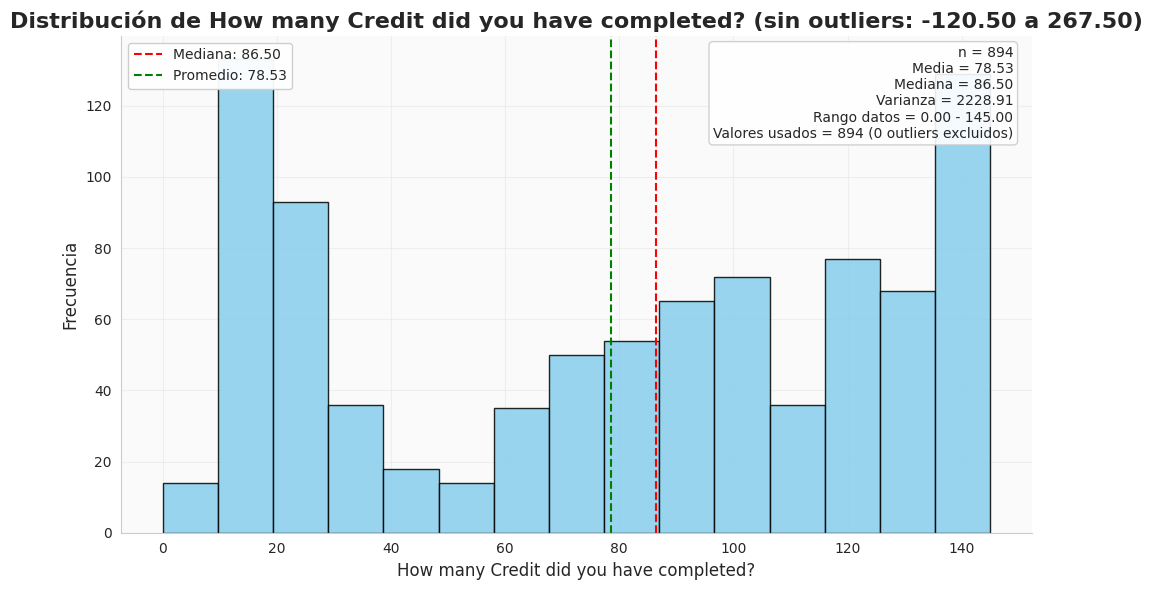


Generando histograma para: What is your monthly Family Income


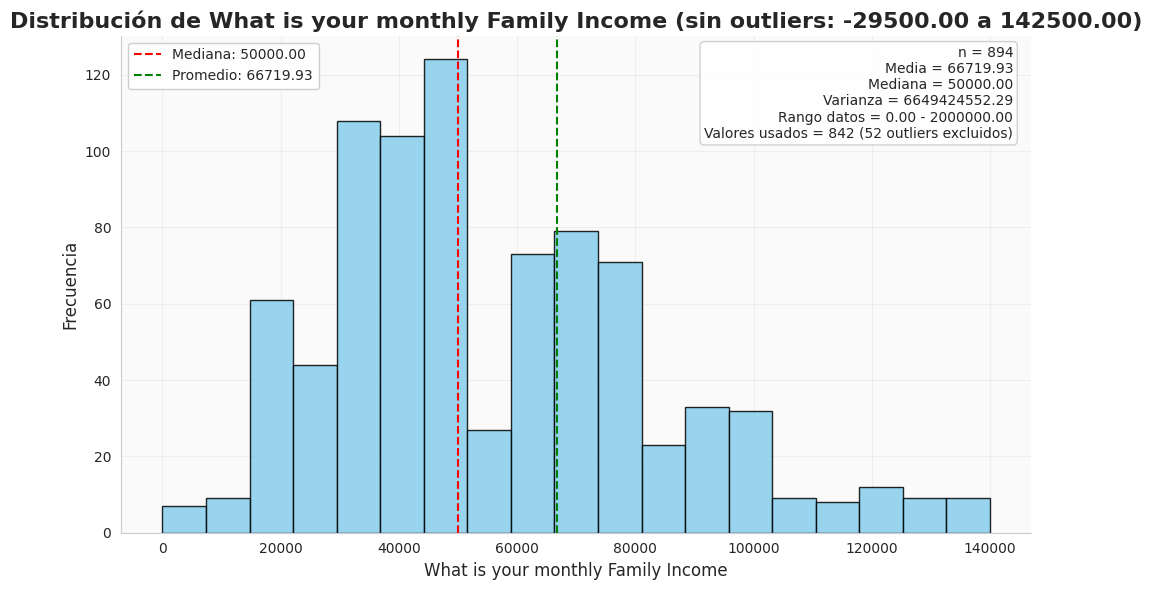

In [19]:
# Verificar las columnas y generar histogramas para cada variable importante
# Normalizar nombres de columnas y la lista de variables importantes
if not df.columns.equals(df.columns.str.strip()):
    df.columns = df.columns.str.strip()

variables_norm = [col.strip() for col in Variables_mas_importante_numericas]
cols_norm = [col.strip() for col in df.columns]

missing = [col for col in variables_norm if col not in cols_norm]
if missing:
    import difflib
    print("Columnas no encontradas en el DataFrame:")
    for col in missing:
        print(f" - {repr(col)}")
        matches = difflib.get_close_matches(col, cols_norm, n=3, cutoff=0.6)
        if matches:
            print(f"   Coincidencias cercanas: {matches}")
    print("\nAsegúrate de que los nombres coincidan exactamente en la lista y en el DataFrame.")
else:
    print("Todas las columnas están presentes. Generando histogramas...")
    for col in variables_norm:
        print(f"\nGenerando histograma para: {col}")
        crear_histogramas_sin_outliers(df, col)

In [20]:
def crear_histogramas_con_outliers(df, columna, bins=None, color="skyblue", titulo=None):
    data = df[columna].dropna()

    # Calcular bins óptimos si no se especifican
    if bins is None:
        if data.nunique() <= 20:
            bins = data.nunique()
        else:
            q75, q25 = np.percentile(data, [75, 25])
            iqr = q75 - q25
            if iqr > 0:
                bin_width = 2 * iqr / (len(data) ** (1/3))
                bins = int(np.ceil((data.max() - data.min()) / bin_width))
                bins = max(15, min(bins, 40))
            else:
                bins = 20

    # Crear figura y eje
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('white')

    # Histograma
    ax.hist(data, bins=bins, color=color, edgecolor='black', alpha=0.85)

    # Títulos
    if titulo is None:
        titulo = f"Distribución de {columna}"
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel(columna, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)

    # Estadística descriptiva
    Mediana = data.median()
    Promedio = data.mean()
    Varianza = data.var()

    # Líneas de estadística descriptiva
    ax.axvline(Mediana, color='red', linestyle='dashed', linewidth=1.5, label=f'Mediana: {Mediana:.2f}')
    ax.axvline(Promedio, color='green', linestyle='dashed', linewidth=1.5, label=f'Promedio: {Promedio:.2f}')
    ax.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10)

    # Información estadística en el gráfico
    stats_text = f'n = {len(data)}\nMedia = {Promedio:.2f}\nMediana = {Mediana:.2f}\nVarianza = {Varianza:.2f}\nRango: {data.min():.2f} - {data.max():.2f}'
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#cccccc'), fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

Todas las columnas están presentes. Generando histogramas...

Generando histograma para: University Admission year


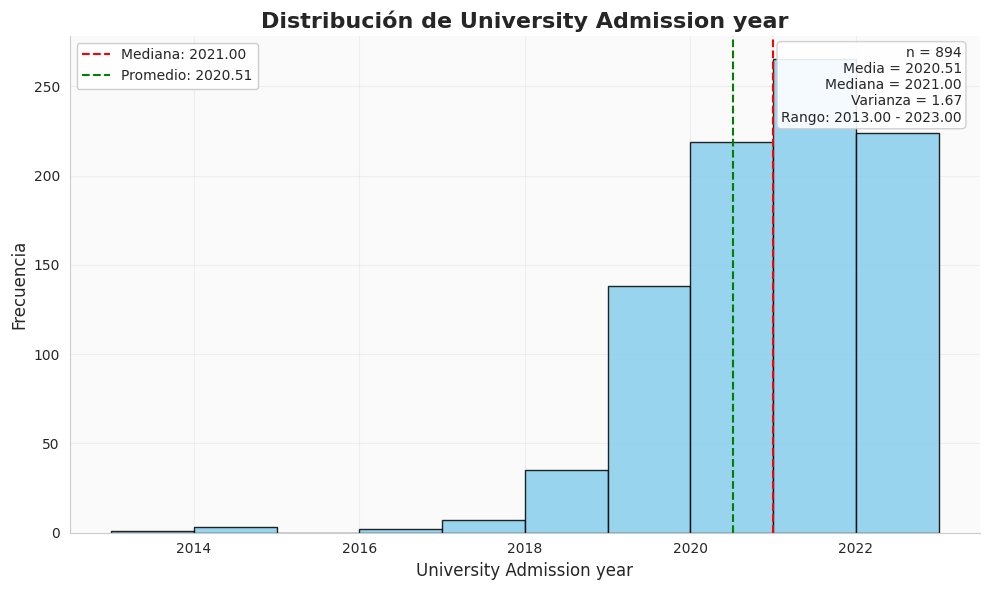


Generando histograma para: Age (Years)


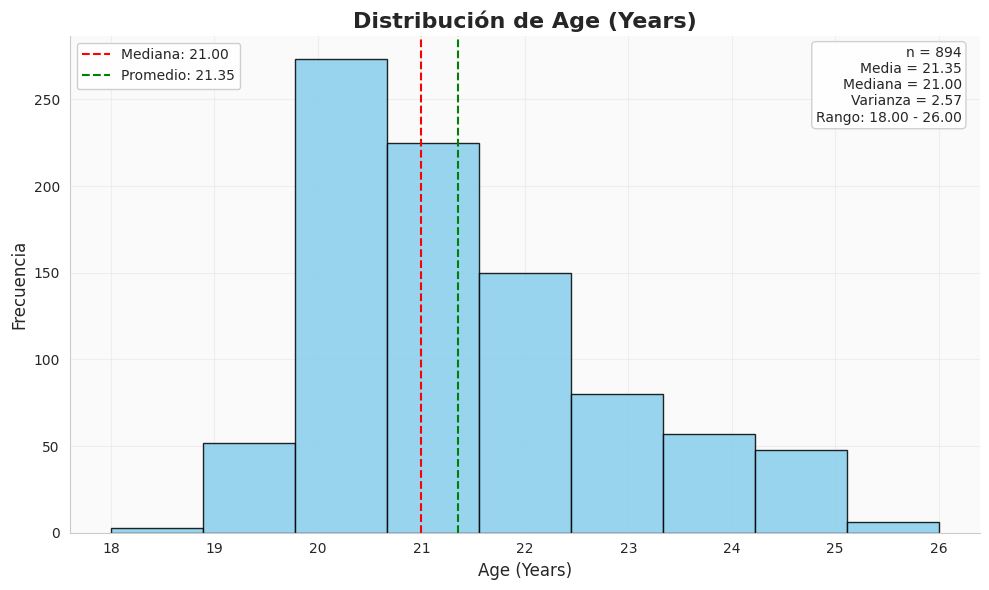


Generando histograma para: H.S.C passing year


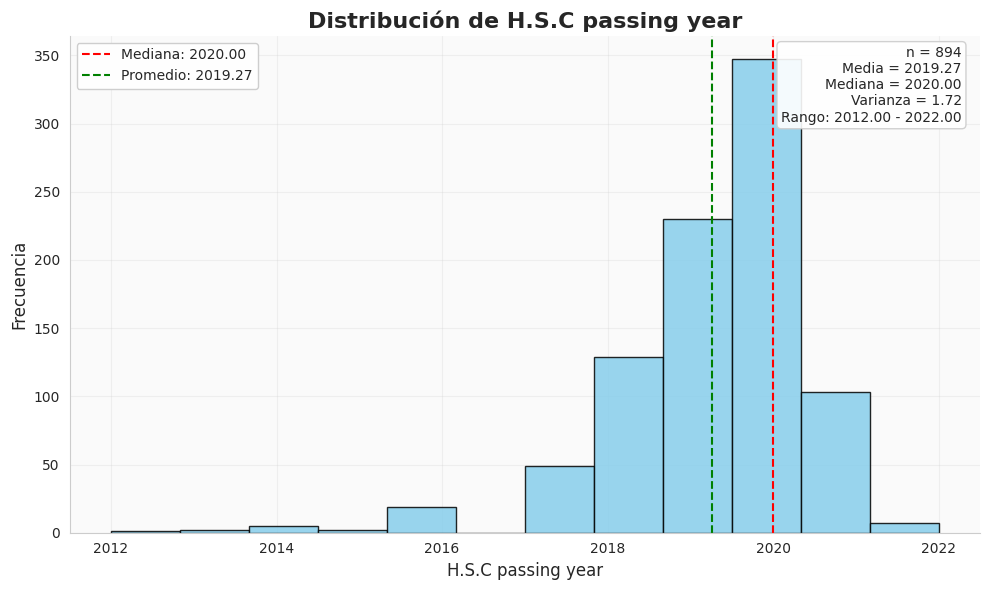


Generando histograma para: Current Semester


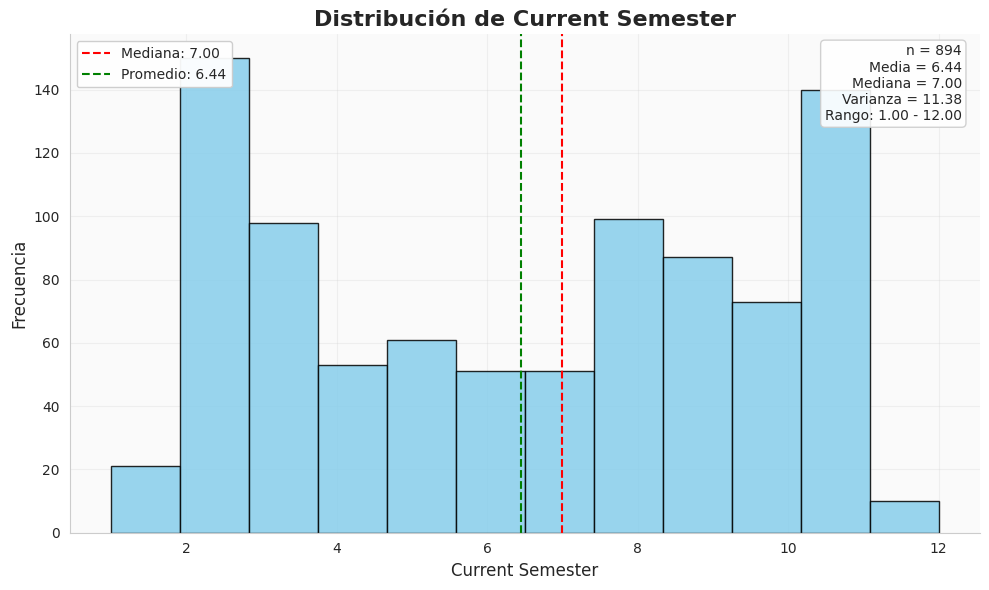


Generando histograma para: How many hour do you study daily? (Hours )


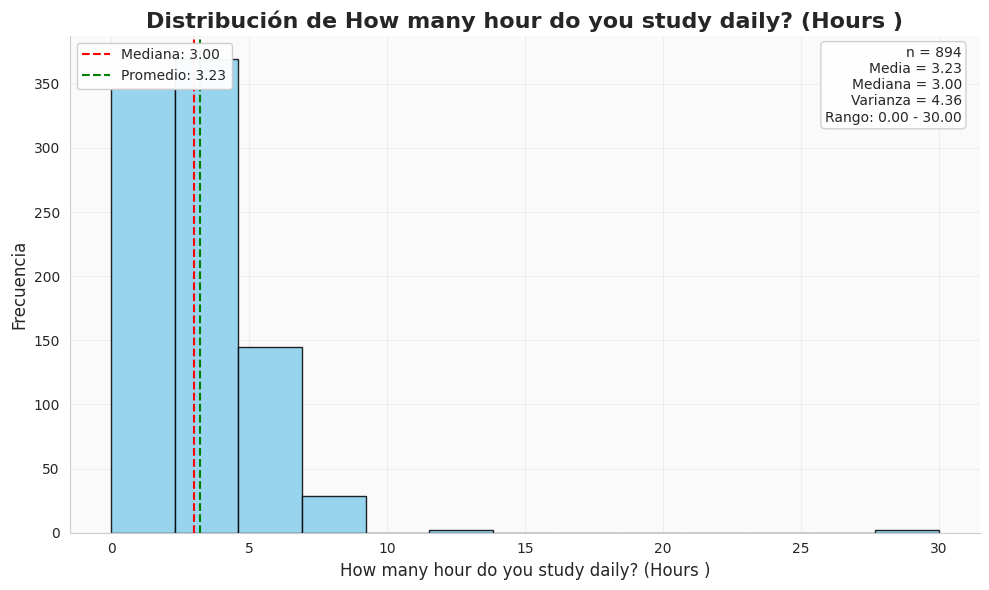


Generando histograma para: How many times do you seat for study in a day?


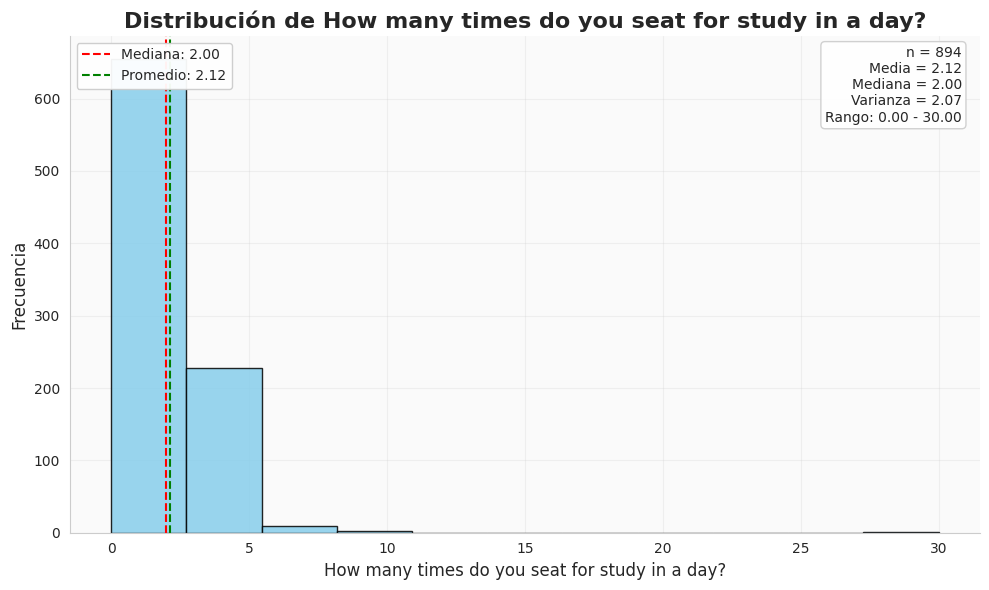


Generando histograma para: How many hour do you spent daily in social media? (Hours)


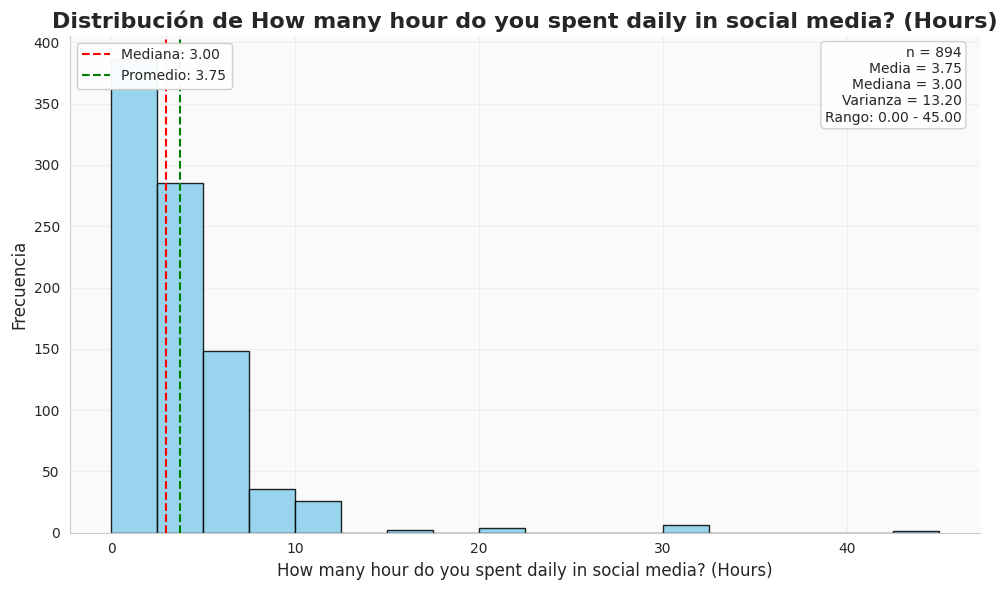


Generando histograma para: Average attendance on class (Percentage )


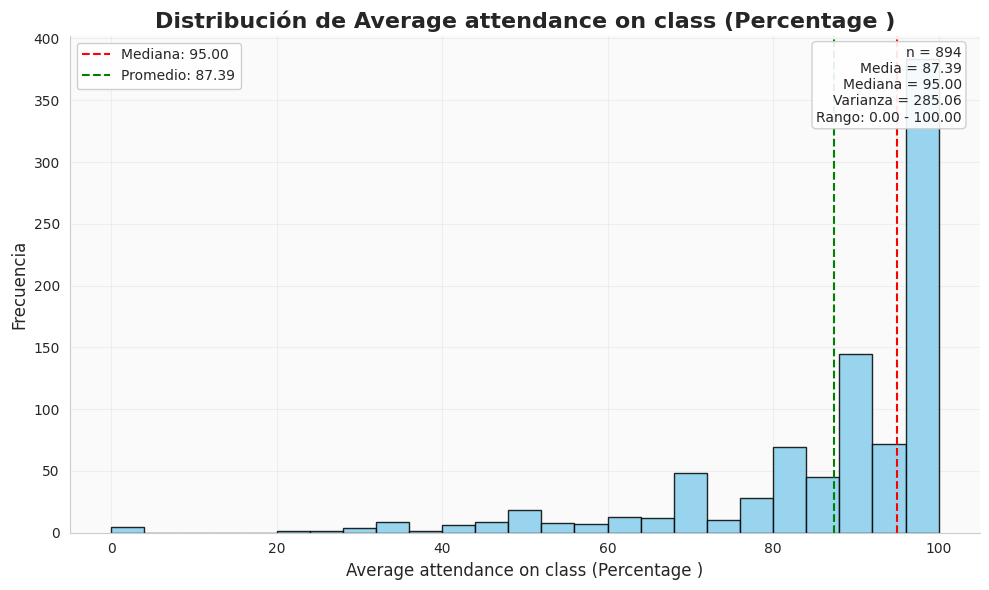


Generando histograma para: How many hour do you spent daily on your skill development? (Hours )


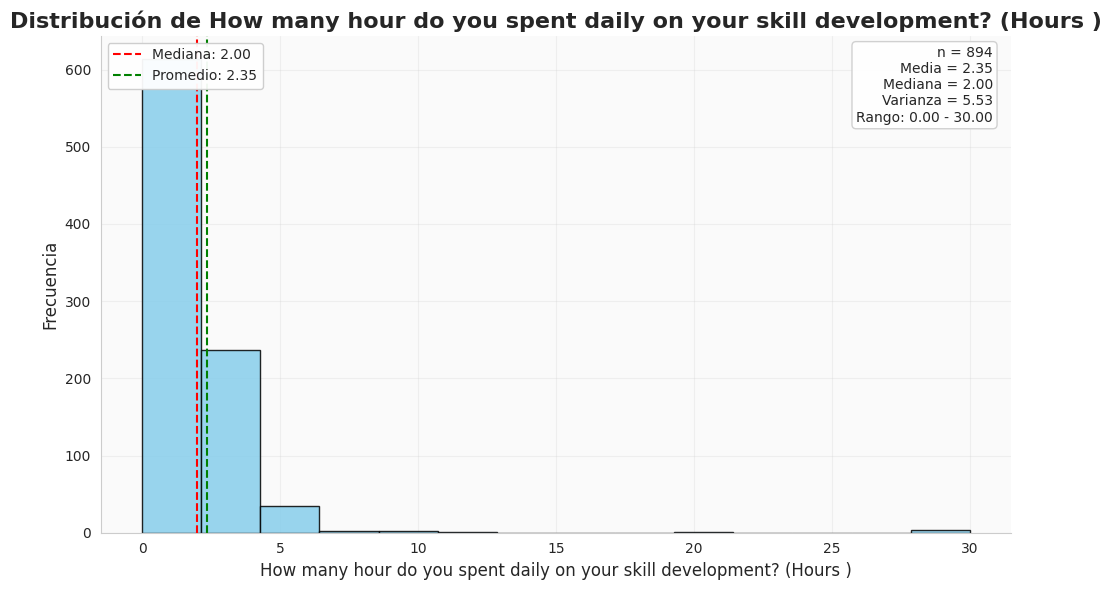


Generando histograma para: What was your previous SGPA?


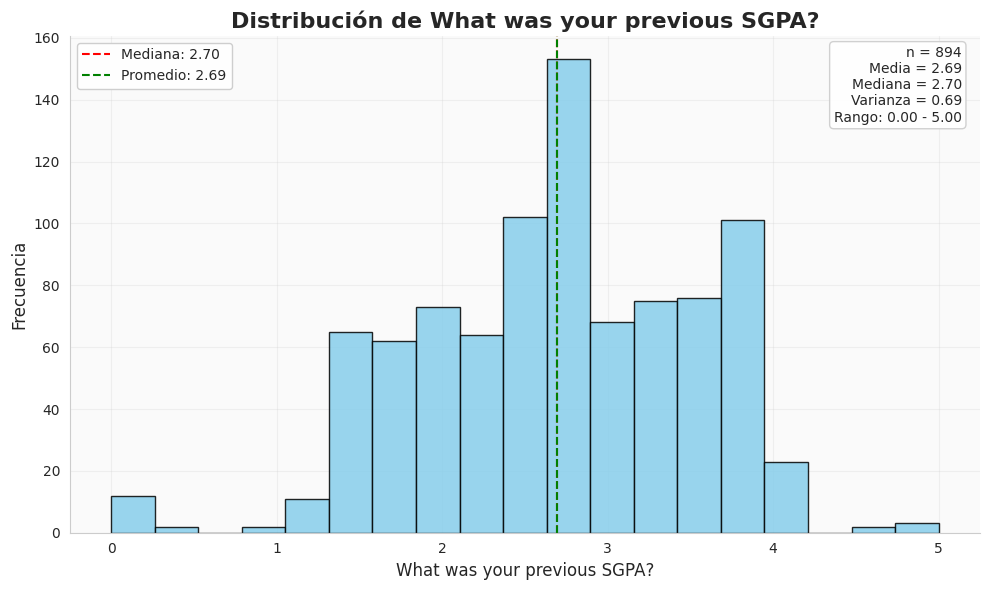


Generando histograma para: What is your current CGPA?


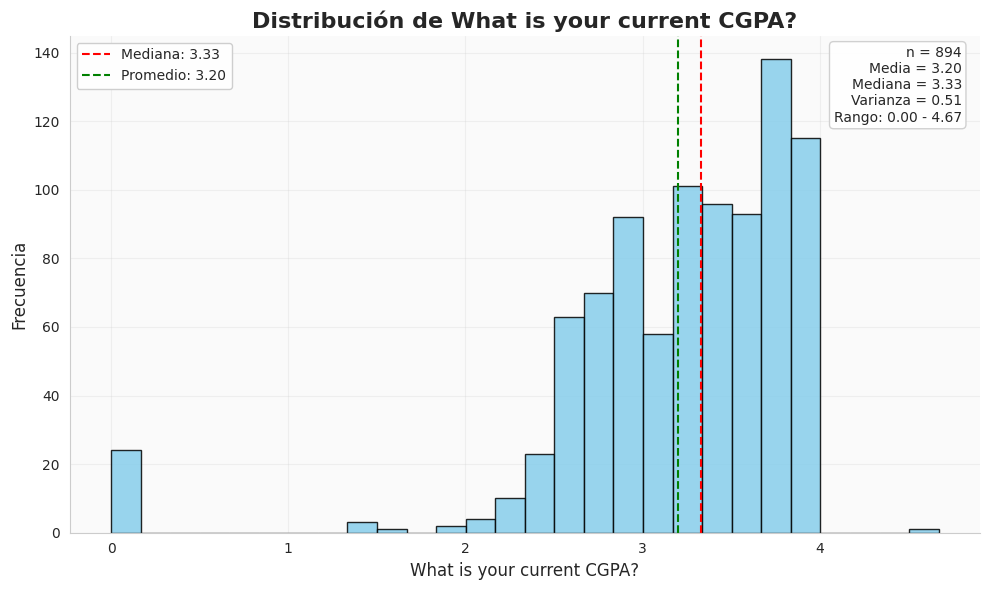


Generando histograma para: How many Credit did you have completed?


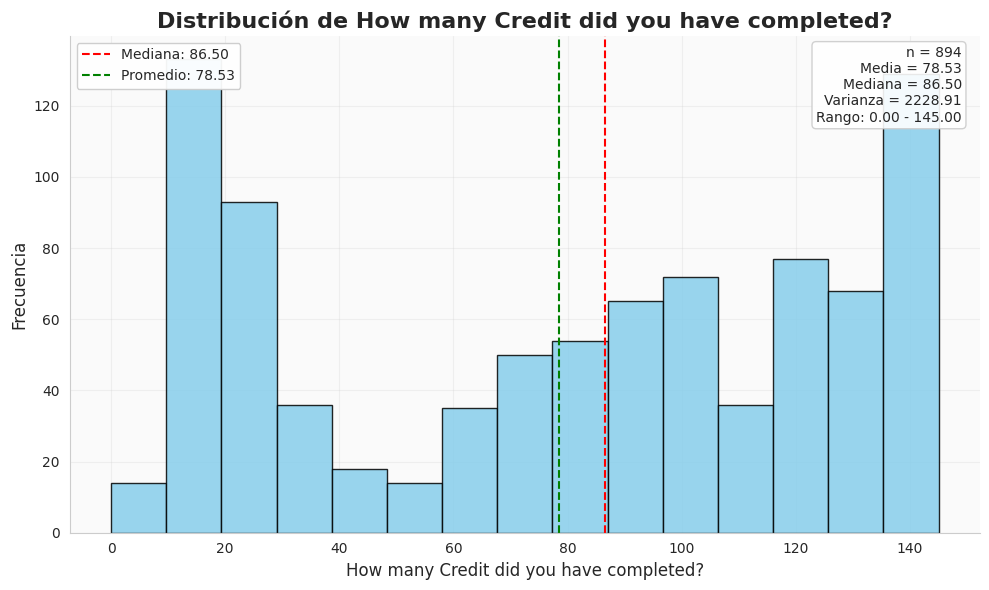


Generando histograma para: What is your monthly Family Income


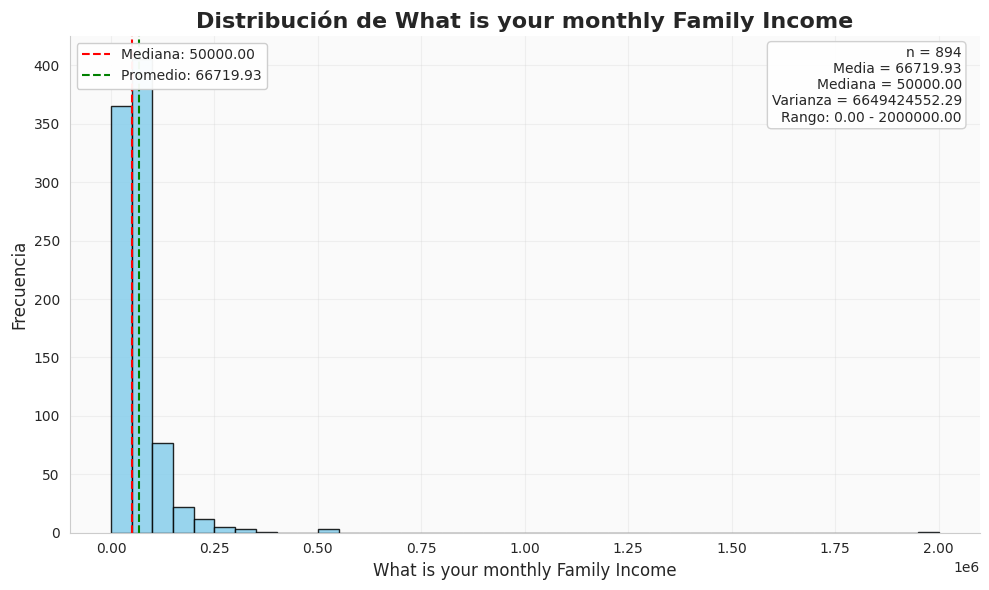

In [21]:
# Verificar las columnas y generar histogramas para cada variable importante
# Normalizar nombres de columnas y la lista de variables importantes
if not df.columns.equals(df.columns.str.strip()):
    df.columns = df.columns.str.strip()

variables_norm = [col.strip() for col in Variables_mas_importante_numericas]
cols_norm = [col.strip() for col in df.columns]

missing = [col for col in variables_norm if col not in cols_norm]
if missing:
    import difflib
    print("Columnas no encontradas en el DataFrame:")
    for col in missing:
        print(f" - {repr(col)}")
        matches = difflib.get_close_matches(col, cols_norm, n=3, cutoff=0.6)
        if matches:
            print(f"   Coincidencias cercanas: {matches}")
    print("\nAsegúrate de que los nombres coincidan exactamente en la lista y en el DataFrame.")
else:
    print("Todas las columnas están presentes. Generando histogramas...")
    for col in variables_norm:
        print(f"\nGenerando histograma para: {col}")
        crear_histogramas_con_outliers(df, col)

# Correlaciones

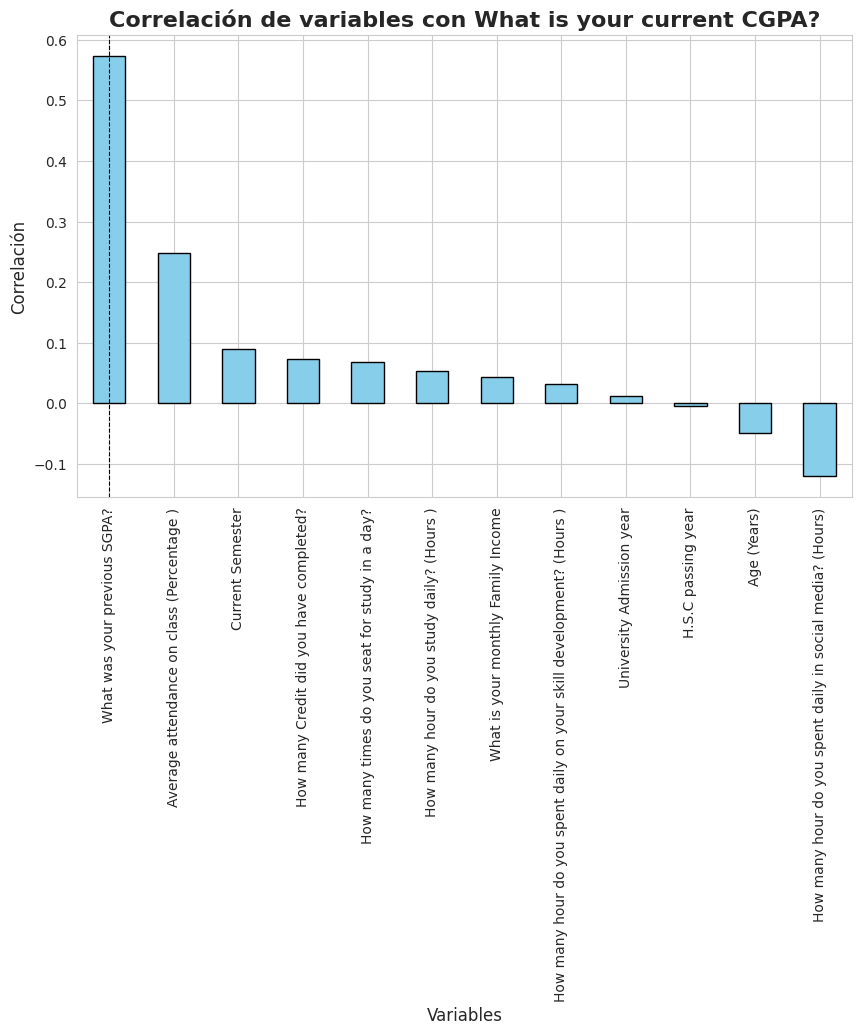

In [22]:
# Calcular correlación con Spearman entre variables numéricas

# Variable objetivo
target="What is your current CGPA?"

# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Correlación con la variable objetivo
corr_target = df_numeric.corr(method='spearman')[target].drop(target).sort_values(ascending=False)

# Grafico
corr_target.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Correlación de variables con {target}', fontsize=16, fontweight='bold')
plt.ylabel('Correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.axvline(x=0, color='black',linestyle='--', linewidth=0.8) #Linea en cero
plt.show()

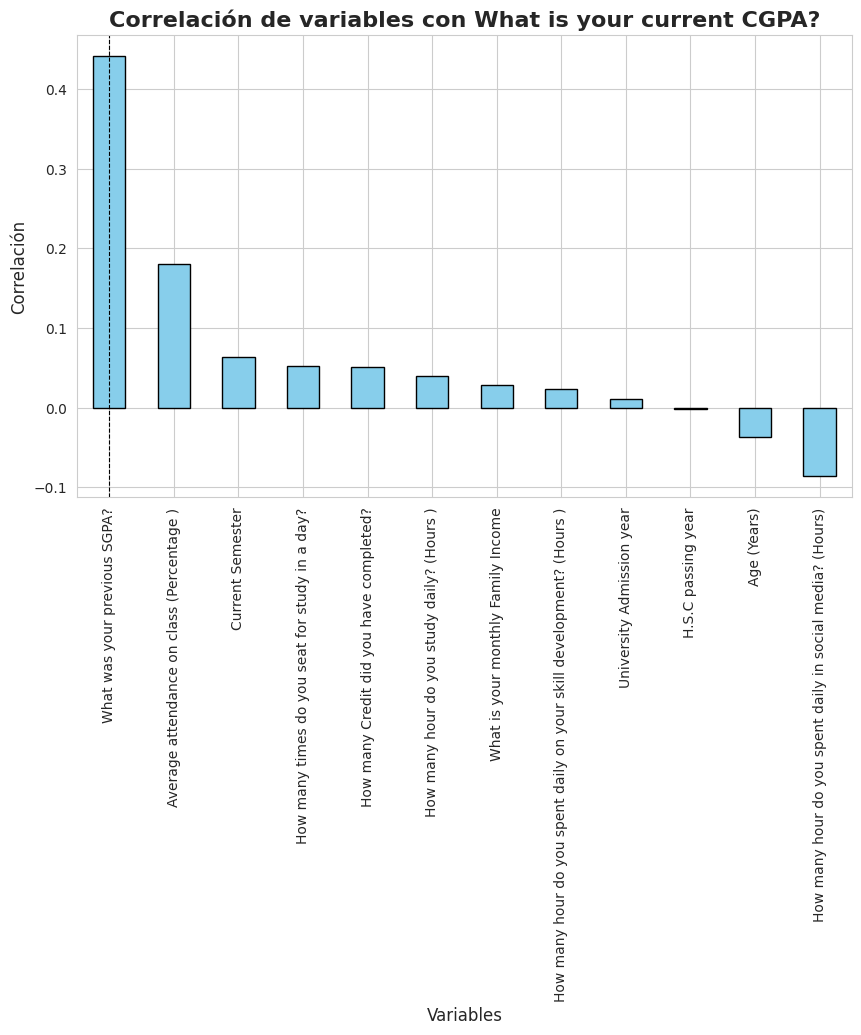

In [23]:
# Calcular correlación con Kendall entre variables numéricas

# Variable objetivo
target="What is your current CGPA?"

# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Correlación con la variable objetivo
corr_target = df_numeric.corr(method='kendall')[target].drop(target).sort_values(ascending=False)

# Grafico
corr_target.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Correlación de variables con {target}', fontsize=16, fontweight='bold')
plt.ylabel('Correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.axvline(x=0, color='black',linestyle='--', linewidth=0.8) #Linea en cero
plt.show()

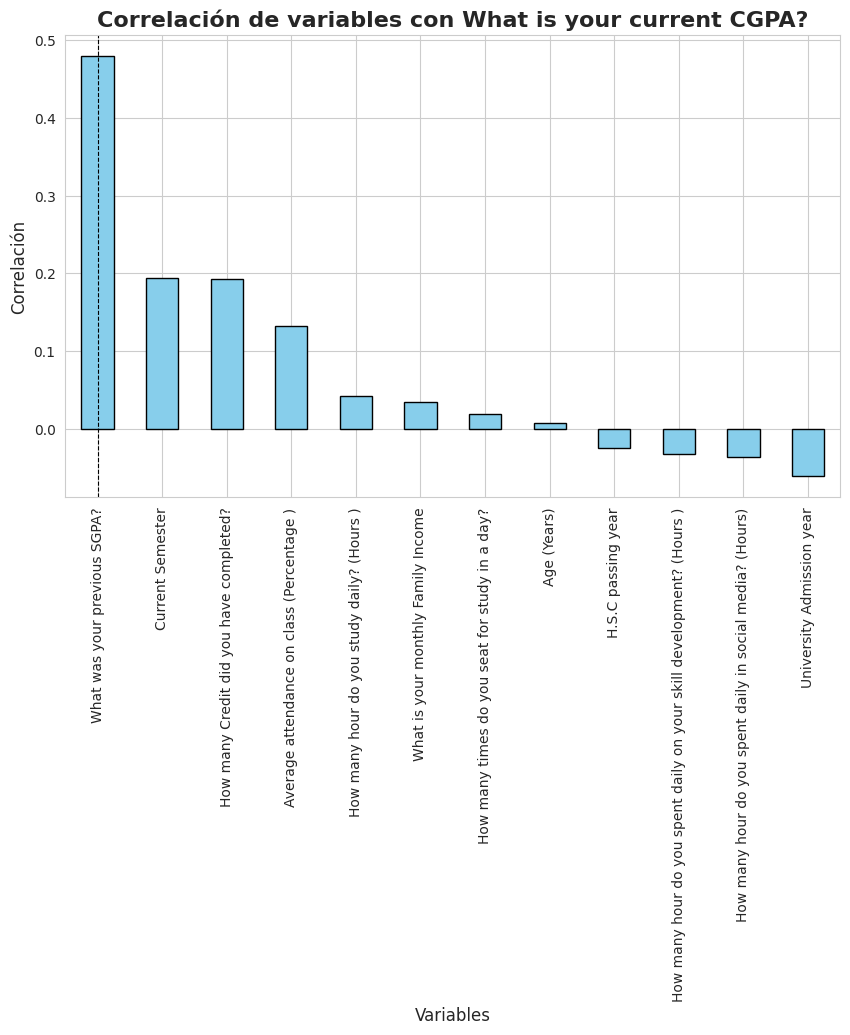

In [24]:
# Calcular correlación con Pearson entre variables numéricas

# Variable objetivo
target="What is your current CGPA?"

# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Correlación con la variable objetivo
corr_target = df_numeric.corr(method='pearson')[target].drop(target).sort_values(ascending=False)

# Grafico
corr_target.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Correlación de variables con {target}', fontsize=16, fontweight='bold')
plt.ylabel('Correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.axvline(x=0, color='black',linestyle='--', linewidth=0.8) #Linea en cero
plt.show()

# Scatter plots


Scatter de CGPA por cada variable numérica:


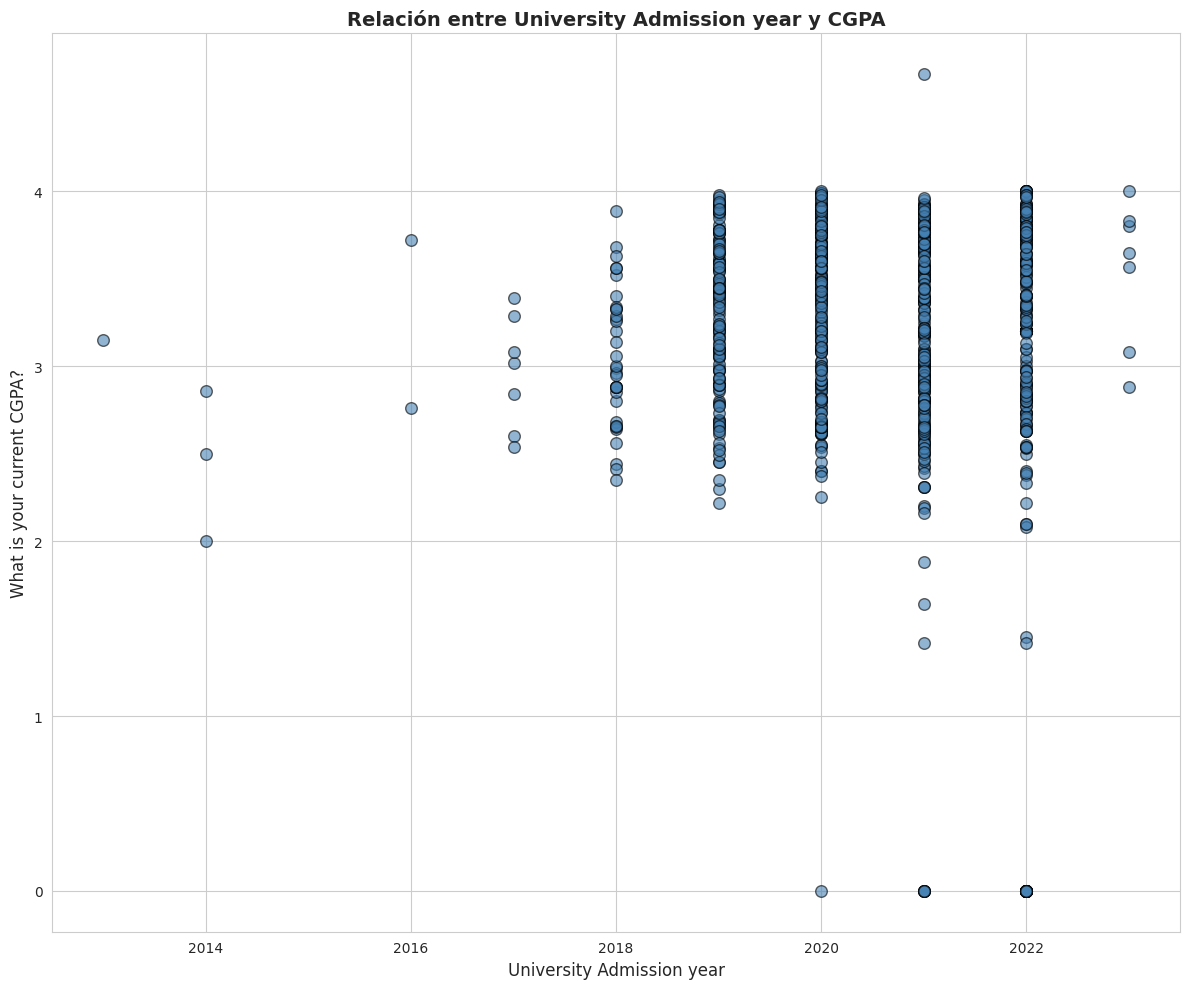

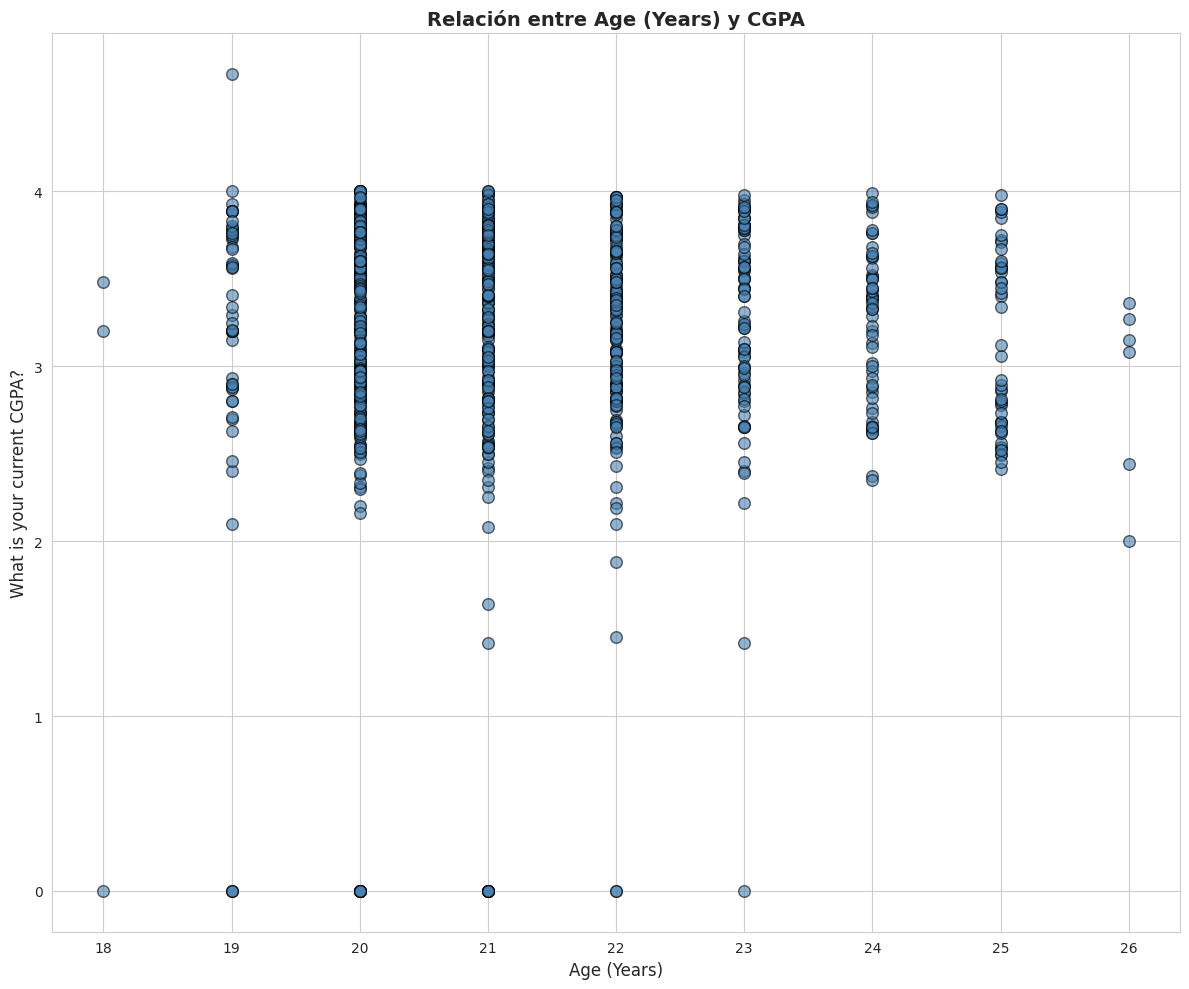

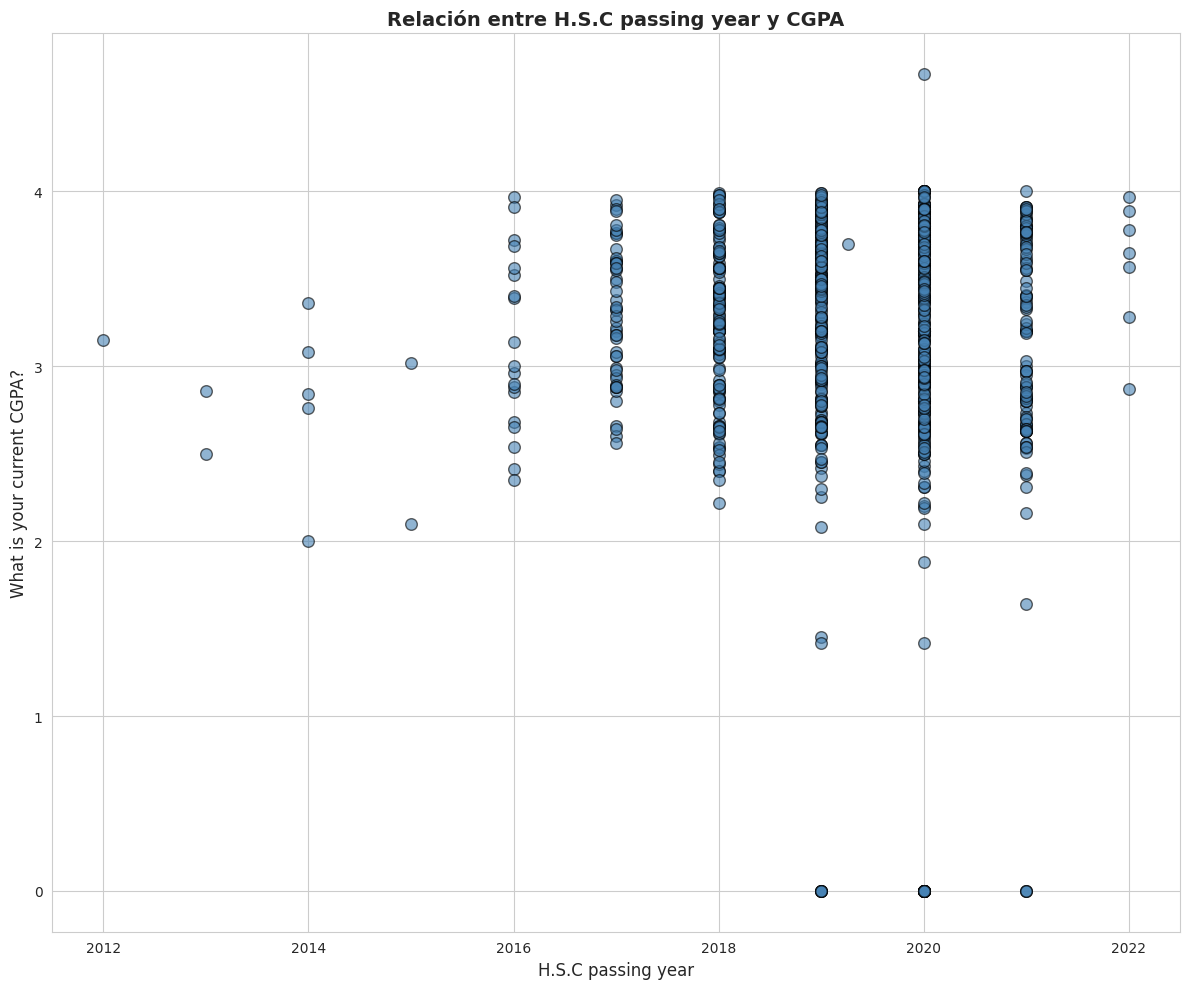

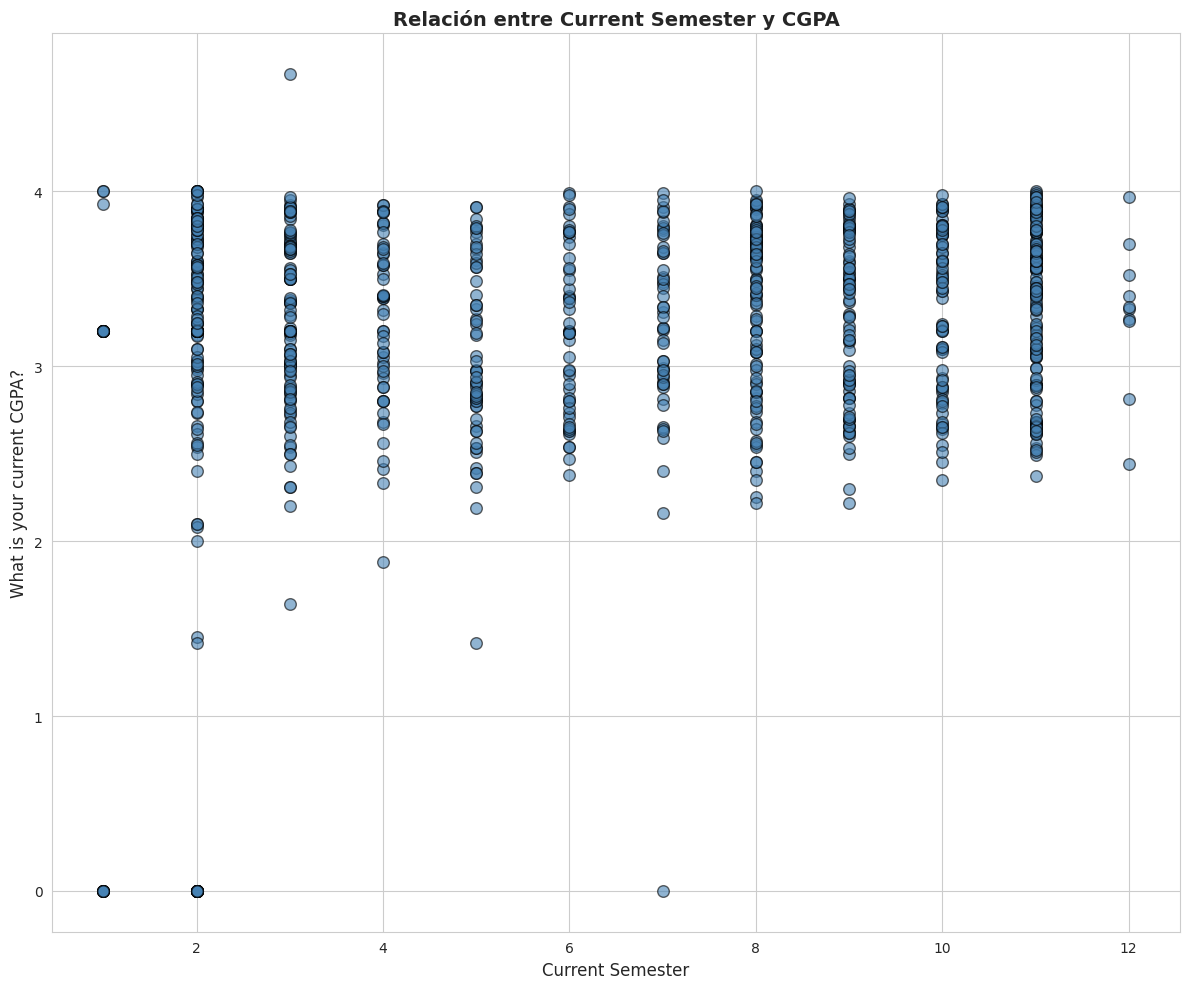

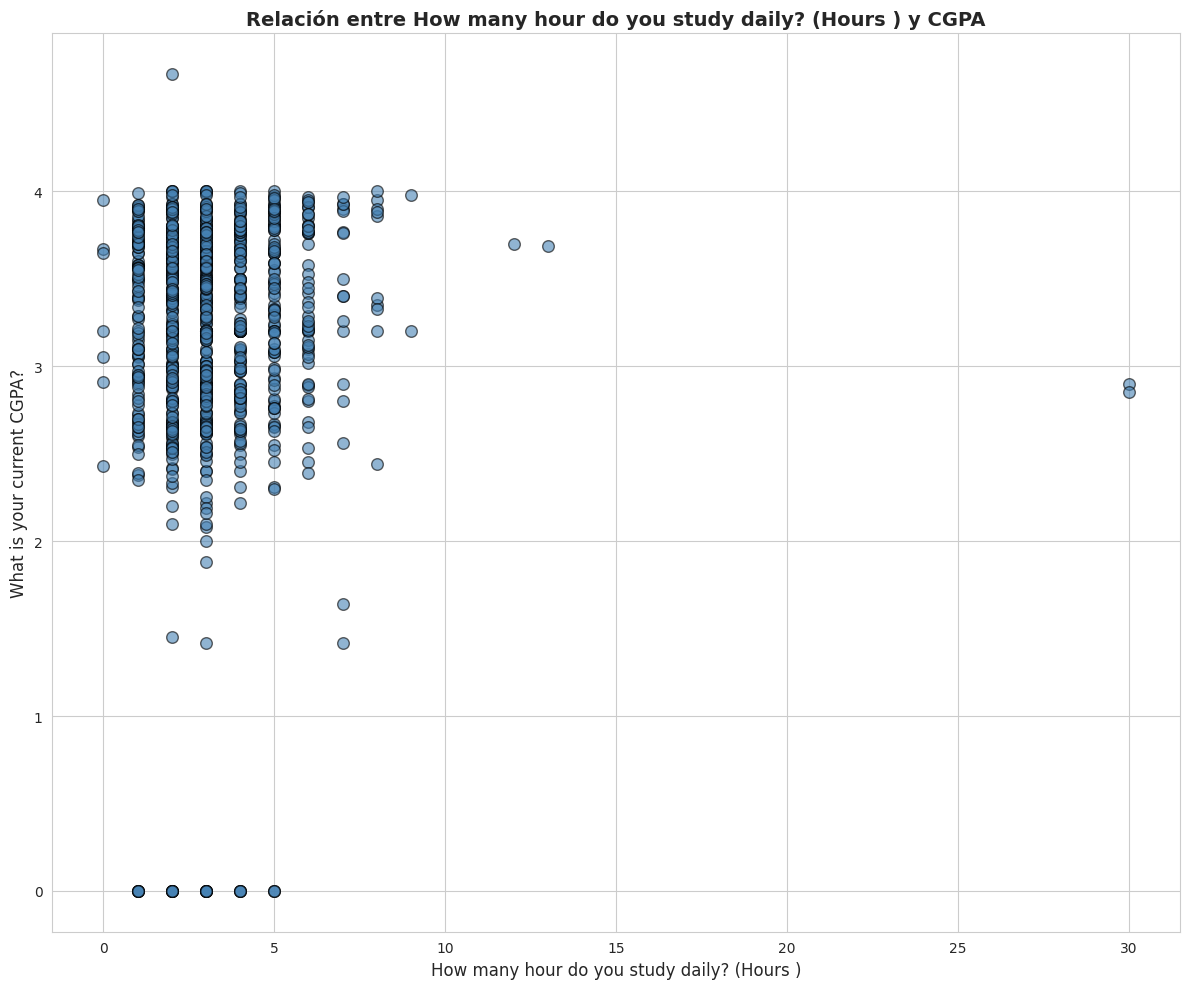

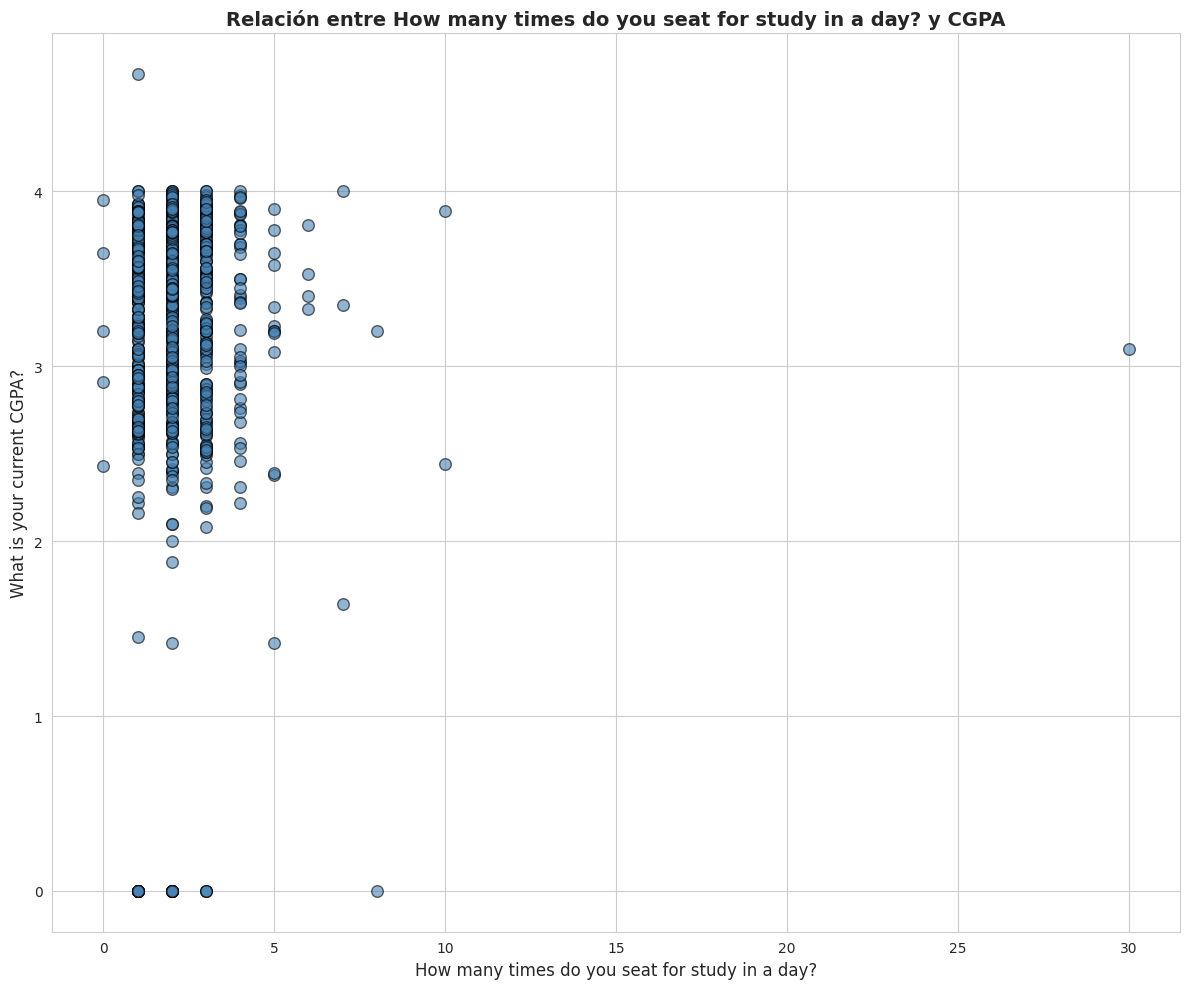

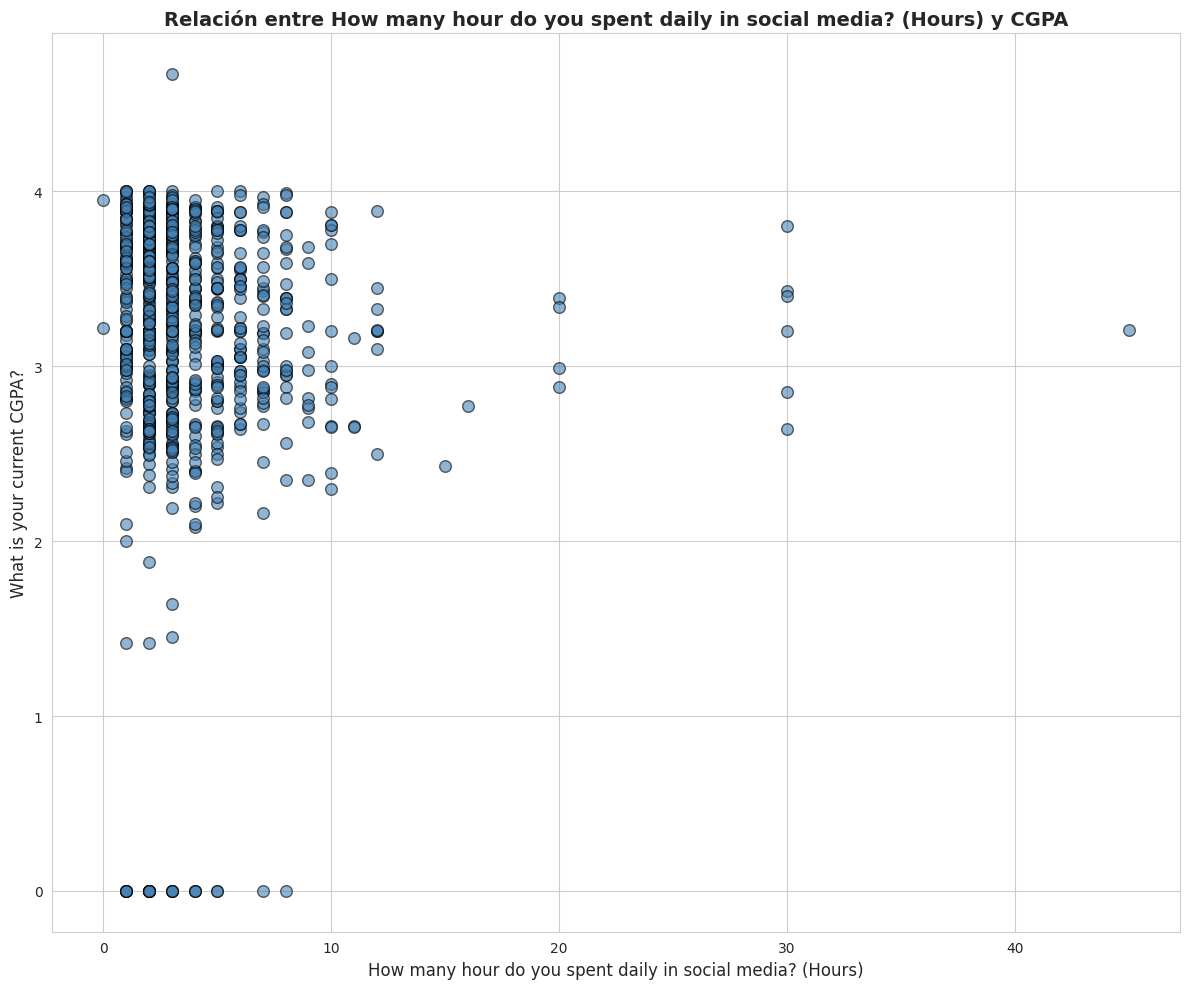

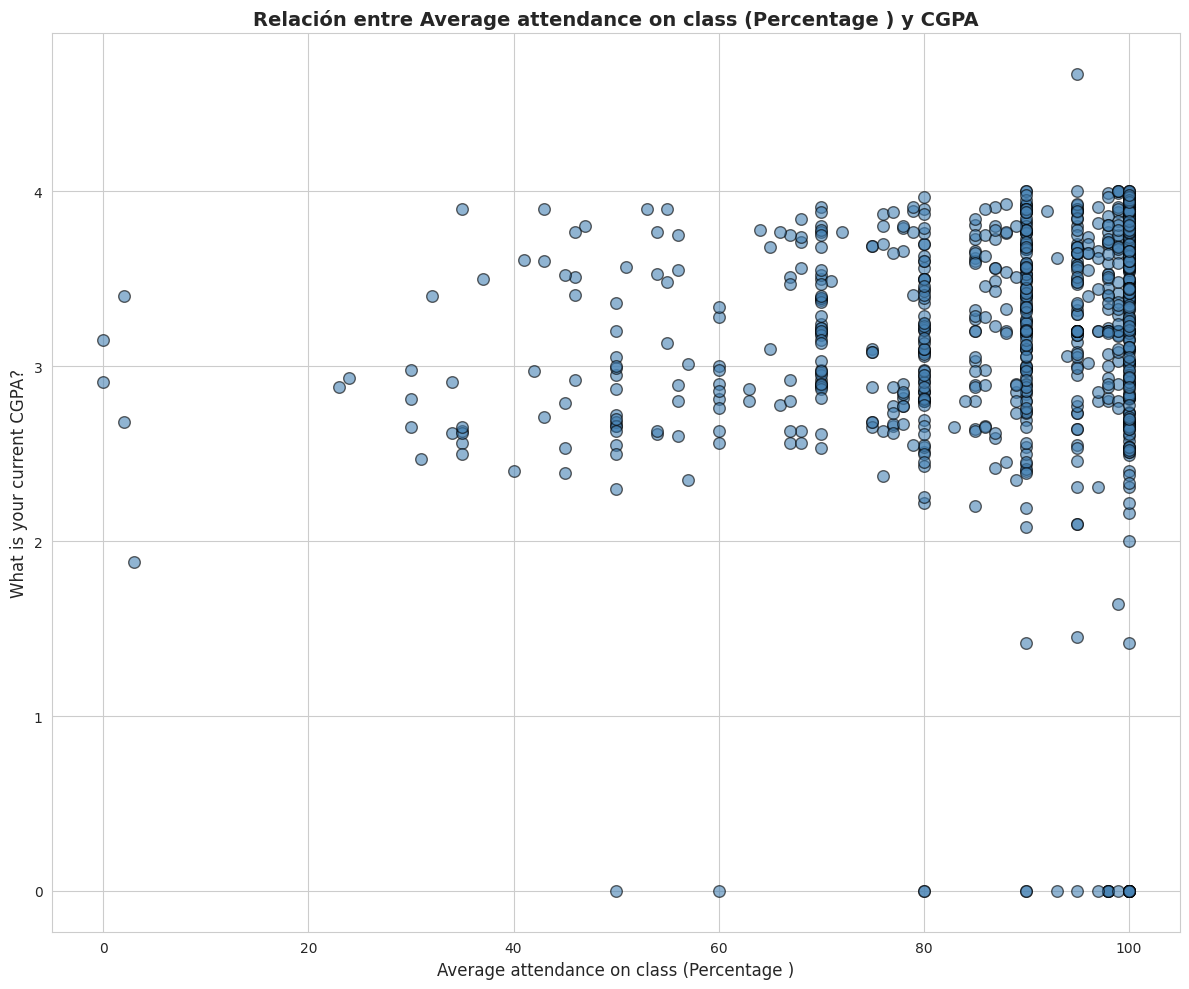

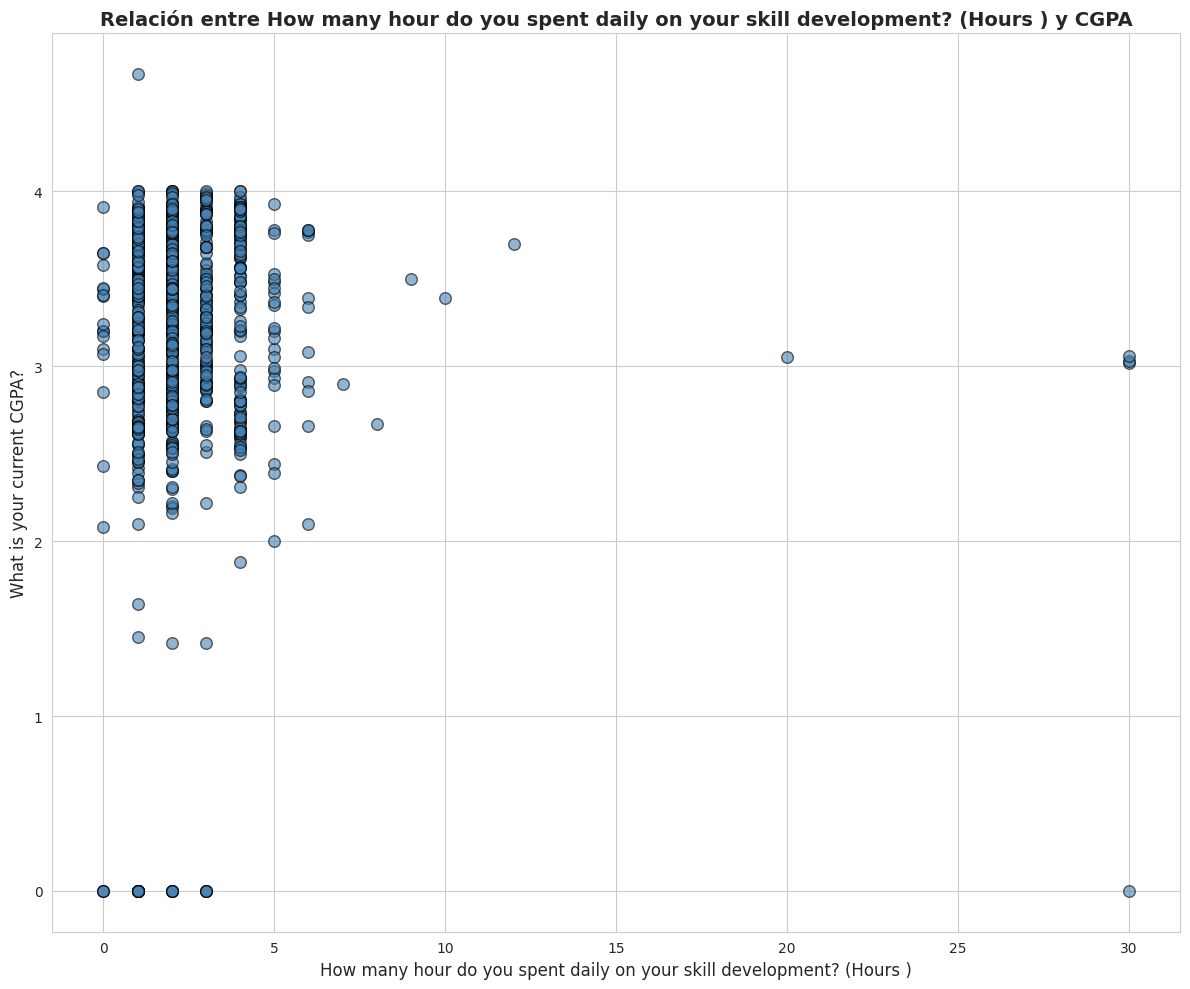

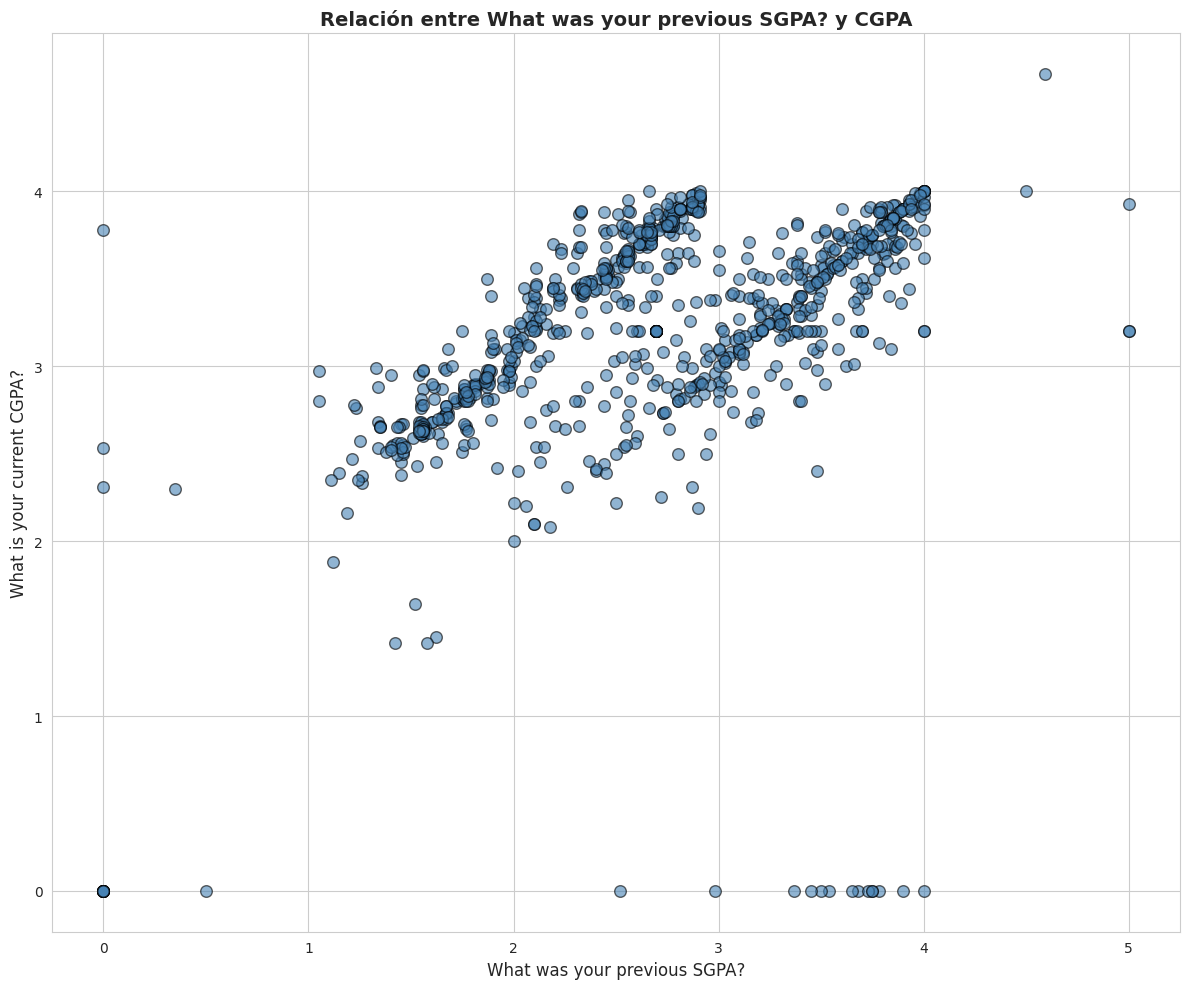

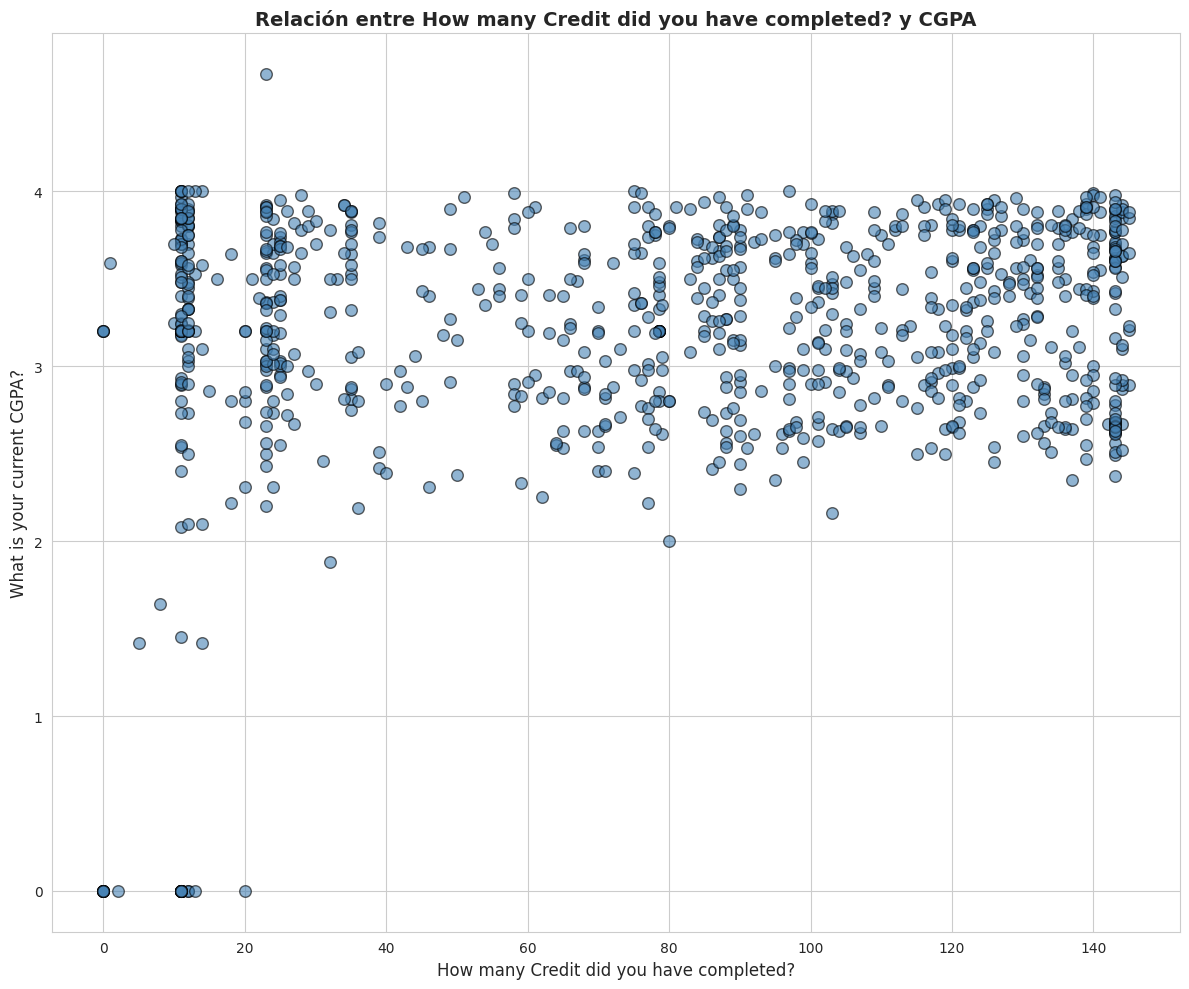

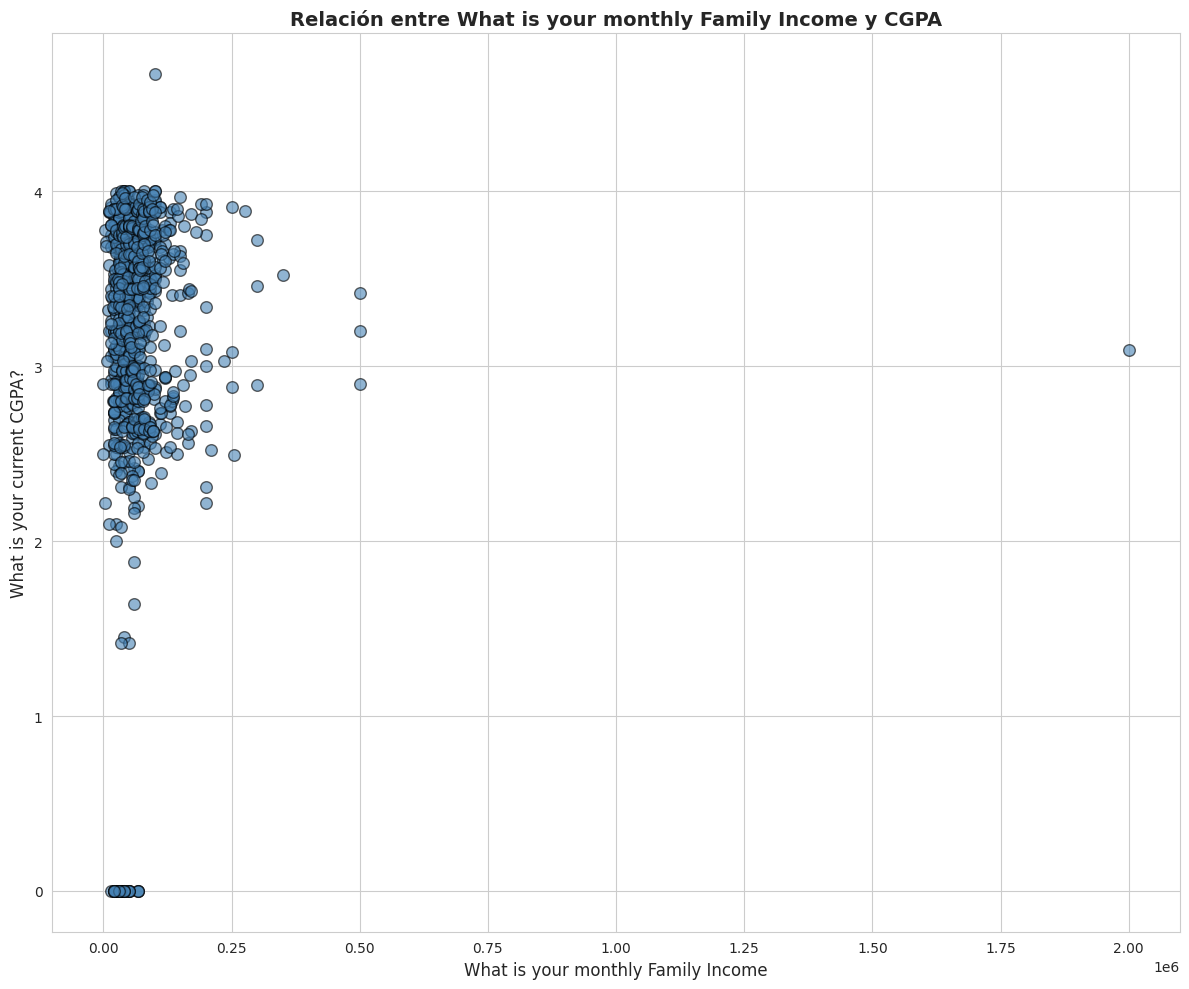

In [25]:
target = "What is your current CGPA?"

# Gráficos de Scatter para visualizar la relación
print("\nScatter de CGPA por cada variable numérica:")
for var in Variables_mas_importante_numericas:
    if var != target:  # No graficar la variable contra sí misma
        # Eliminar filas con NaN en ambas columnas
        temp_df = df[[var, target]].dropna()
        
        if len(temp_df) > 0:
            plt.figure(figsize=(12, 10))
            plt.scatter(temp_df[var], temp_df[target], alpha=0.6, edgecolors='k', s=70, color='steelblue')
            plt.title(f'Relación entre {var} y CGPA', fontsize=14, fontweight='bold')
            plt.xlabel(var, fontsize=12)
            plt.ylabel(target, fontsize=12)
            plt.grid(True, alpha=1)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Sin datos válidos para {var}")

# 5. Pruebas de asociación y dependencia

## Prueba chi-cuadrado para variables categoricas

In [29]:
from scipy.stats import chi2_contingency

def prueba_chi(df,cate=Variables_mas_importante_categoricas, alpha=0.05):

    # Interfaz usuario:
    print("\n PRUEBA CHI-CUADRADO DE INDEPENDENCIA")
    print("\n Objetivo: Evaluar si existe una asociación estadísticamente significativa entre pares de variables categóricas")
    print("\n Elija un número para la información que proporcionara la prueba:")
    print("\n 1. Todas las comparaciones")
    print("\n 2. Solo con Dependencia")
    print("\n 3. Solo con Independencia")

    resultado=input("\n Elija un número:")

    if resultado=='1':
        print("\n TODAS LAS COMPARACIONES")
        for var1, var2 in combinations(cate,2):

            # Tabla de contingencia
            tabla=pd.crosstab(df[var1],df[var2])

            #Prueba Chi-cuadrado
            chi2,p,dof,expected=chi2_contingency(tabla)

            print("="*150)
            print(f"\n {var1} -- VS -- {var2} ")
            print(f"\n Estadistico: {chi2:.4f}, p-valor: {p:.4f}")
            if p<alpha:
                print(f"\n CONCLUCIÓN: Existe evidencia de dependencia entre las variables")
            else:
                print(f"\n CONCLUCIÓN: No hay evidencia sufiente de dependencia entre las variables")

    if resultado=='2':
        print("\n VARIABLES CON DEPENDENCIA")
        for var1, var2 in combinations(cate,2):

            # Tabla de contingencia
            tabla=pd.crosstab(df[var1],df[var2])

            #Prueba Chi-cuadrado
            chi2,p,dof,expected=chi2_contingency(tabla)

            if p<alpha:
                print("="*150)
                print(f"\n {var1} -- VS -- {var2} ")
                print(f"\n Estadistico: {chi2:.4f}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: Existe evidencia de dependencia entre las variables")

    if resultado=='3':
        print("\n VARIABLES CON INDEPENDENCIA")
        for var1, var2 in combinations(cate,2):

            # Tabla de contingencia
            tabla=pd.crosstab(df[var1],df[var2])

            #Prueba Chi-cuadrado
            chi2,p,dof,expected=chi2_contingency(tabla)

            if p>=alpha:
                print("="*150)
                print(f"\n {var1} -- VS -- {var2} ")
                print(f"\n Estadistico: {chi2:.4f}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: No hay evidencia sufiente de dependencia entre las variables")

        
prueba_chi(df)


 PRUEBA CHI-CUADRADO DE INDEPENDENCIA

 Objetivo: Evaluar si existe una asociación estadísticamente significativa entre pares de variables categóricas

 Elija un número para la información que proporcionara la prueba:

 1. Todas las comparaciones

 2. Solo con Dependencia

 3. Solo con Independencia

 VARIABLES CON DEPENDENCIA

 Gender -- VS -- Do you have meritorious scholarship ? 

 Estadistico: 7.5712, p-valor: 0.0059

 CONCLUCIÓN: Existe evidencia de dependencia entre las variables

 Gender -- VS -- What is your relationship status? 

 Estadistico: 20.1089, p-valor: 0.0002

 CONCLUCIÓN: Existe evidencia de dependencia entre las variables

 Gender -- VS -- With whom you are living with? 

 Estadistico: 26.6704, p-valor: 0.0000

 CONCLUCIÓN: Existe evidencia de dependencia entre las variables

 Do you have meritorious scholarship ? -- VS -- Do you use University transportation? 

 Estadistico: 13.2799, p-valor: 0.0003

 CONCLUCIÓN: Existe evidencia de dependencia entre las variables

## Prueba de Spearman para variables númericas

In [31]:
from scipy.stats import spearmanr

def prueba_spearmanr(df,num=Variables_mas_importante_numericas, alpha=0.05):

    # Interfaz usuario:
    print("\n PRUEBA DE CORRELACIÓN DE SPEARMANR")
    print("\n Objetivo: Evaluar la fuerza y dirrección de la asociación monótona entre\n pares de variables numéricas")
    print("\n Elija un número para la información que proporcionara la prueba:")
    print("\n 1. Todas las comparaciones")
    print("\n 2. Solo asociación monótona")
    print("\n 3. Solo sin asociación monótona ")

    resultado=input("\n Elija un número:")

    if resultado=='1':
        print("\n TODAS LAS COMPARACIONES DE VARIABLES")
        for var1, var2 in combinations(num,2):

            #Prueba Spearmanr
            coef,p=spearmanr(df[var1],df[var2])

            fuerza=""
            if abs(coef)<0.3:
                fuerza="Débil"
            elif abs(coef)< 0.7:
                fuerza="Moderada"
            else:
                fuerza="Fuerte"

            direccion="Positiva" if coef>0 else "Negativa"

            print("="*150)
            print(f"\n {var1} -- VS -- {var2} ")
            print(f"\n Coeficiente: {round(abs(coef),5)}, Fuerza: {fuerza}, Dirección: {direccion}, p-valor: {p:.4f}")
            if p<alpha:
                print(f"\n CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables")
            else:
                print(f"\n CONCLUCIÓN: No hay evidencia suficiente de asociación monótona significativa entre las variables")

    if resultado=='2':
         print("\n VARIABLES CON ASOCIACIÓN MONÓTONA SIGNIFICATIVA")
         for var1, var2 in combinations(num,2):

            #Prueba Spearmanr
            coef,p=spearmanr(df[var1],df[var2])

            fuerza=""
            if abs(coef)<0.3:
                fuerza="Débil"
            elif abs(coef)< 0.7:
                fuerza="Moderada"
            else:
                fuerza="Fuerte"

            direccion="Positiva" if coef>0 else "Negativa"

            if p<alpha:
                print("="*150)
                print(f"\n {var1} -- VS -- {var2} ")
                print(f"\n Coeficiente: {round(abs(coef),5)}, Fuerza: {fuerza}, Dirección: {direccion}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables")

    if resultado=='3':
         print("\n VARIABLES SIN ASOCIACIÓN MONÓTONA")
         for var1, var2 in combinations(num,2):

            #Prueba Spearmanr
            coef,p=spearmanr(df[var1],df[var2])

            fuerza=""
            if abs(coef)<0.3:
                fuerza="Débil"
            elif abs(coef)< 0.7:
                fuerza="Moderada"
            else:
                fuerza="Fuerte"

            direccion="Positiva" if coef>0 else "Negativa"

            if p>=alpha:
                print("="*150)
                print(f"\n {var1} -- VS -- {var2} ")
                print(f"\n Coeficiente: {round(abs(coef),5)}, Fuerza: {fuerza}, Dirección: {direccion}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: No hay evidencia suficiente de asociación monótona significativa entre las variables")

prueba_spearmanr(df)


 PRUEBA DE CORRELACIÓN DE SPEARMANR

 Objetivo: Evaluar la fuerza y dirrección de la asociación monótona entre
 pares de variables numéricas

 Elija un número para la información que proporcionara la prueba:

 1. Todas las comparaciones

 2. Solo asociación monótona

 3. Solo sin asociación monótona 



 VARIABLES CON ASOCIACIÓN MONÓTONA SIGNIFICATIVA

 University Admission year -- VS -- Age (Years) 

 Coeficiente: 0.58437, Fuerza: Moderada, Dirección: Negativa, p-valor: 0.0000

 CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables

 University Admission year -- VS -- H.S.C passing year 

 Coeficiente: 0.74695, Fuerza: Fuerte, Dirección: Positiva, p-valor: 0.0000

 CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables

 University Admission year -- VS -- Current Semester 

 Coeficiente: 0.66699, Fuerza: Moderada, Dirección: Negativa, p-valor: 0.0000

 CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables

 University Admission year -- VS -- Average attendance on class (Percentage ) 

 Coeficiente: 0.10147, Fuerza: Débil, Dirección: Positiva, p-valor: 0.0024

 CONCLUCIÓN: Existe evidencia de asociación monótona significativa entre las variables

 University Admission year -- VS -- How many

## Prueba de Kruskal-Wallis

In [32]:
from scipy.stats import kruskal

def prueba_kruskal(df,num=Variables_mas_importante_numericas, cate=Variables_mas_importante_categoricas, alpha=0.05):

    # Interfaz usuario:
    print("\n PRUEBA KRUSKAL-WALLIS (ANOVA NO PARAMÉTRICA)")
    print("\n Objetivo: Determinar si la distribución de una variable numérica difiere significativamente \n  entre los grupos definidos por una variable categorica")
    print("\n Elija un número para la información que proporcionara la prueba:")
    print("\n 1. Todas las comparaciones")
    print("\n 2. Solo diferencias significativas")
    print("\n 3. Solo sin diferencias significativas")

    resultado=input("\n Elija un número:")

    n_obs=len(df)

    if resultado=='1':
        print("\n VARIABLES CON Y SIN DIFERENCIAS")
        for var1, var2 in product(num,cate):

            grupos=[df[var1][df[var2]==cat] for cat in df[var2].unique() ]

            if len(grupos)<2: continue
            k=len(grupos)
        
            # Prueba Kruskal
            h_stat,p=kruskal(*grupos)

            # Tamaño del efecto
            epsilon_sq=max(0,(h_stat-k+1)/(n_obs-k))

            fuerza=""
            if epsilon_sq<0.01:
                fuerza="Despreciable"
            elif epsilon_sq< 0.08:
                fuerza="Pequeño"
            elif epsilon_sq<0.26:
                fuerza="Moderada"
            else:
                fuerza="Grande"

            print("="*150)
            print(f"\n  Distribución de '{var1}' según las categorias de '{var2}' ")
            print(f"\n H_estadístico: {h_stat:.4f}, Tamaño del efecto: {fuerza}, p-valor: {p:.4f}")
            if p<alpha:
                print(f"\n CONCLUCIÓN: La distribución de '{var1}' varia significativamente entre \n al menos dos categorias de '{var2}' ")
            else:
                print(f"\n CONCLUCIÓN: No hay evidencia sufiente para afirmar diferencias en la distribución de '{var1}' entre \n las categotias de '{var2}' ")

    if resultado=='2':
         print("\n VARIABLES CON DIFERENCIAS ESTIDÍSTICAMENTE SIGNIFICATIVAS")
         for var1, var2 in product(num,cate):

            grupos=[df[var1][df[var2]==cat] for cat in df[var2].unique() ]

            if len(grupos)<2: continue
            k=len(grupos)
        
            # Prueba Kruskal
            h_stat,p=kruskal(*grupos)

            # Tamaño del efecto
            epsilon_sq=max(0,(h_stat-k+1)/(n_obs-k))

            fuerza=""
            if epsilon_sq<0.01:
                fuerza="Despreciable"
            elif epsilon_sq< 0.08:
                fuerza="Pequeño"
            elif epsilon_sq<0.26:
                fuerza="Moderada"
            else:
                fuerza="Grande"

            if p<alpha:
                print("="*150)
                print(f"\n  Distribución de '{var1}' según las categorias de '{var2}' ")
                print(f"\n H_estadístico: {h_stat:.4f}, Tamaño del efecto: {fuerza}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: La distribución de '{var1}' varia significativamente entre \n al menos dos categorias de '{var2}' ")

    if resultado=='3':
        print("\n VARIABLES SIN DIFERENCIAS ESTIDÍSTICAMENTE SIGNIFICATIVAS")
        for var1, var2 in product(num,cate):

            grupos=[df[var1][df[var2]==cat] for cat in df[var2].unique() ]

            if len(grupos)<2: continue
            k=len(grupos)
        
            # Prueba Kruskal
            h_stat,p=kruskal(*grupos)

            # Tamaño del efecto
            epsilon_sq=max(0,(h_stat-k+1)/(n_obs-k))

            fuerza=""
            if epsilon_sq<0.01:
                fuerza="Despreciable"
            elif epsilon_sq< 0.08:
                fuerza="Pequeño"
            elif epsilon_sq<0.26:
                fuerza="Moderada"
            else:
                fuerza="Grande"

            if p>=alpha:
                print("="*150)
                print(f"\n  Distribución de '{var1}' según las categorias de '{var2}' ")
                print(f"\n H_estadístico: {h_stat:.4f}, Tamaño del efecto: {fuerza}, p-valor: {p:.4f}")
                print(f"\n CONCLUCIÓN: No hay evidencia sufiente para afirmar diferencias en la distribución de '{var1}' entre \n las categotias de '{var2}' ")
        
prueba_kruskal(df)


 PRUEBA KRUSKAL-WALLIS (ANOVA NO PARAMÉTRICA)

 Objetivo: Determinar si la distribución de una variable numérica difiere significativamente 
  entre los grupos definidos por una variable categorica

 Elija un número para la información que proporcionara la prueba:

 1. Todas las comparaciones

 2. Solo diferencias significativas

 3. Solo sin diferencias significativas



 VARIABLES SIN DIFERENCIAS ESTIDÍSTICAMENTE SIGNIFICATIVAS

  Distribución de 'University Admission year' según las categorias de 'Gender' 

 H_estadístico: 2.1355, Tamaño del efecto: Despreciable, p-valor: 0.1439

 CONCLUCIÓN: No hay evidencia sufiente para afirmar diferencias en la distribución de 'University Admission year' entre 
 las categotias de 'Gender' 

  Distribución de 'University Admission year' según las categorias de 'Do you use University transportation?' 

 H_estadístico: 0.0221, Tamaño del efecto: Despreciable, p-valor: 0.8817

 CONCLUCIÓN: No hay evidencia sufiente para afirmar diferencias en la distribución de 'University Admission year' entre 
 las categotias de 'Do you use University transportation?' 

  Distribución de 'University Admission year' según las categorias de 'What is your preferable learning mode?' 

 H_estadístico: 3.7298, Tamaño del efecto: Despreciable, p-valor: 0.0535

 CONCLUCIÓN: No hay evidencia sufiente para afirmar diferencias en la distribu